# Exploration de la Base de Données

## Objectif

Ce notebook a pour objectif d'explorer en profondeur le dataset Ames Housing pour comprendre sa structure, identifier les valeurs manquantes, analyser les corrélations, traiter les outliers, transformer la variable cible, et effectuer des tests ANOVA sur les variables qualitatives.

**Principales étapes** :
- Analyse descriptive complète des données
- Détection et traitement des valeurs manquantes
- Identification et traitement des valeurs aberrantes (outliers)
- Transformation logarithmique de la variable cible (SalePrice → SalePrice_log)
- Analyse de corrélation pour les variables quantitatives
- Tests ANOVA pour identifier les variables qualitatives significatives
- Sauvegarde des données traitées

## Prérequis

**Aucun prérequis** - Ce notebook est le point de départ du pipeline.

Ce notebook utilise les données brutes (`data/raw/train.csv` et `data/raw/test.csv`) et génère les fichiers suivants :
- `data/processed/train_outliers_treated.csv` - Données d'entraînement après traitement des outliers
- `data/processed/test_outliers_treated.csv` - Données de test après traitement des outliers
- `data/processed/train_final.csv` - Données finales avec variable cible transformée (SalePrice_log)

**À exécuter avant** : Aucun (notebook de départ)


In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Bibliothèques importées avec succès")


Bibliothèques importées avec succès


## 1. Chargement et Aperçu Initial


In [2]:
# Chargement des données
import pandas as pd

# Chargement des données
train_df = pd.read_csv('../data/processed/train_cleaned.csv', keep_default_na=False, na_filter=False)
test_df = pd.read_csv('../data/processed/test_cleaned.csv', keep_default_na=False, na_filter=False)

print("=" * 60)
print("INFORMATIONS GÉNÉRALES SUR LE DATASET")
print("=" * 60)
print(f"\nDonnees d'entrainement:")
print(f"   - Nombre de lignes: {train_df.shape[0]:,}")
print(f"   - Nombre de colonnes: {train_df.shape[1]}")
print(f"   - Taille memoire: {train_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nDonnees de test:")
print(f"   - Nombre de lignes: {test_df.shape[0]:,}")
print(f"   - Nombre de colonnes: {test_df.shape[1]}")
print(f"   - Taille memoire: {test_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nDifference:")
print(f"   - Colonnes dans train mais pas dans test: {set(train_df.columns) - set(test_df.columns)}")
print(f"   - Colonnes dans test mais pas dans train: {set(test_df.columns) - set(train_df.columns)}")

# Vérification de la variable cible
print("\n" + "=" * 60)
print("VERIFICATION DE LA VARIABLE CIBLE (SalePrice)")
print("=" * 60)

if 'SalePrice' in train_df.columns:
    missing_target = train_df['SalePrice'].isnull().sum()
    print(f"\nValeurs manquantes dans SalePrice: {missing_target}")
    if missing_target == 0:
        print("OK: La variable cible n'a aucune valeur manquante")
    else:
        print(f"ATTENTION: {missing_target} valeurs manquantes dans la variable cible!")
        print(f"Pourcentage: {(missing_target / len(train_df)) * 100:.2f}%")
else:
    print("ATTENTION: La variable SalePrice n'est pas presente dans le dataset d'entrainement!")

# Analyse de cohérence entre train et test
print("\n" + "=" * 60)
print("ANALYSE DE COHERENCE TRAIN vs TEST")
print("=" * 60)

# Colonnes communes
common_cols = set(train_df.columns) & set(test_df.columns)
print(f"\nColonnes communes: {len(common_cols)}")

# Colonnes uniquement dans train
train_only = set(train_df.columns) - set(test_df.columns)
if train_only:
    print(f"\nColonnes uniquement dans TRAIN ({len(train_only)}):")
    for col in sorted(train_only):
        print(f"   - {col}")

# Colonnes uniquement dans test
test_only = set(test_df.columns) - set(train_df.columns)
if test_only:
    print(f"\nColonnes uniquement dans TEST ({len(test_only)}):")
    for col in sorted(test_only):
        print(f"   - {col}")

# Vérification des types de données
print("\nVerification des types de donnees:")
type_mismatches = []
for col in common_cols:
    if train_df[col].dtype != test_df[col].dtype:
        type_mismatches.append({
            'Colonne': col,
            'Type Train': train_df[col].dtype,
            'Type Test': test_df[col].dtype
        })

if type_mismatches:
    print(f"\nATTENTION: {len(type_mismatches)} colonnes ont des types differents:")
    for mismatch in type_mismatches:
        print(f"   - {mismatch['Colonne']}: Train={mismatch['Type Train']}, Test={mismatch['Type Test']}")
else:
    print("OK: Tous les types de donnees sont coherents entre train et test")

# Vérification des valeurs uniques pour les variables catégorielles
print("\nVerification des valeurs categorielles:")
categorical_cols_common = [col for col in common_cols 
                           if train_df[col].dtype == 'object' and test_df[col].dtype == 'object']

value_mismatches = []
for col in categorical_cols_common:
    train_values = set(train_df[col].dropna().unique())
    test_values = set(test_df[col].dropna().unique())
    
    # Valeurs dans test mais pas dans train
    test_only_values = test_values - train_values
    if test_only_values:
        value_mismatches.append({
            'Colonne': col,
            'Valeurs dans test mais pas dans train': test_only_values,
            'Nombre': len(test_only_values)
        })

if value_mismatches:
    print(f"\nATTENTION: {len(value_mismatches)} colonnes categorielles ont des valeurs dans test absentes de train:")
    for mismatch in value_mismatches[:10]:  # Limiter à 10 pour l'affichage
        print(f"   - {mismatch['Colonne']}: {mismatch['Nombre']} valeurs uniques")
        if len(mismatch['Valeurs dans test mais pas dans train']) <= 5:
            print(f"     Valeurs: {mismatch['Valeurs dans test mais pas dans train']}")
    if len(value_mismatches) > 10:
        print(f"   ... et {len(value_mismatches) - 10} autres colonnes")
else:
    print("OK: Toutes les valeurs categorielles du test sont presentes dans le train")

# Statistiques comparatives
print("\n" + "=" * 60)
print("STATISTIQUES COMPARATIVES")
print("=" * 60)

print(f"\nNombre d'observations:")
print(f"   Train: {len(train_df):,}")
print(f"   Test: {len(test_df):,}")
print(f"   Ratio Test/Train: {len(test_df)/len(train_df):.2f}")

# Comparaison des plages de valeurs pour les variables numériques clés
print("\nComparaison des plages de valeurs (variables numeriques cles):")
key_numeric = ['LotArea', 'YearBuilt', 'GrLivArea', 'TotalBsmtSF', 'GarageArea']
for col in key_numeric:
    if col in common_cols and train_df[col].dtype in ['int64', 'float64']:
        train_min, train_max = train_df[col].min(), train_df[col].max()
        test_min, test_max = test_df[col].min(), test_df[col].max()
        
        # Vérifier si les valeurs de test sont dans la plage de train
        out_of_range = (test_min < train_min) or (test_max > train_max)
        
        print(f"\n   {col}:")
        print(f"      Train: [{train_min:.2f}, {train_max:.2f}]")
        print(f"      Test:  [{test_min:.2f}, {test_max:.2f}]")
        if out_of_range:
            print(f"      ATTENTION: Valeurs hors de la plage d'entrainement!")
        else:
            print(f"      OK: Toutes les valeurs sont dans la plage d'entrainement")


INFORMATIONS GÉNÉRALES SUR LE DATASET

Donnees d'entrainement:
   - Nombre de lignes: 1,460
   - Nombre de colonnes: 81
   - Taille memoire: 3.58 MB

Donnees de test:
   - Nombre de lignes: 1,459
   - Nombre de colonnes: 80
   - Taille memoire: 3.57 MB

Difference:
   - Colonnes dans train mais pas dans test: {'SalePrice'}
   - Colonnes dans test mais pas dans train: set()

VERIFICATION DE LA VARIABLE CIBLE (SalePrice)

Valeurs manquantes dans SalePrice: 0
OK: La variable cible n'a aucune valeur manquante

ANALYSE DE COHERENCE TRAIN vs TEST

Colonnes communes: 80

Colonnes uniquement dans TRAIN (1):
   - SalePrice

Verification des types de donnees:

ATTENTION: 7 colonnes ont des types differents:
   - BsmtHalfBath: Train=int64, Test=float64
   - BsmtFinSF1: Train=int64, Test=float64
   - BsmtFullBath: Train=int64, Test=float64
   - BsmtUnfSF: Train=int64, Test=float64
   - GarageCars: Train=int64, Test=float64
   - BsmtFinSF2: Train=int64, Test=float64
   - GarageArea: Train=int64, Te

In [3]:
# Aperçu des premières lignes
print("=" * 60)
print("APERÇU DES PREMIÈRES LIGNES")
print("=" * 60)
train_df.head()


APERÇU DES PREMIÈRES LIGNES


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0


## 2. Structure des Données


In [4]:
# Types de données
print("=" * 60)
print("TYPES DE DONNÉES PAR COLONNE")
print("=" * 60)

# Séparer les colonnes numériques et catégorielles
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nColonnes numeriques ({len(numeric_cols)}):")
print(f"   {', '.join(numeric_cols[:10])}...")
if len(numeric_cols) > 10:
    print(f"   ... et {len(numeric_cols) - 10} autres")

print(f"\nColonnes categorielles ({len(categorical_cols)}):")
print(f"   {', '.join(categorical_cols[:10])}...")
if len(categorical_cols) > 10:
    print(f"   ... et {len(categorical_cols) - 10} autres")

# Afficher les types
print("\n" + "=" * 60)
print("RÉSUMÉ DES TYPES")
print("=" * 60)
type_summary = train_df.dtypes.value_counts()
for dtype, count in type_summary.items():
    print(f"   {dtype}: {count} colonnes")


TYPES DE DONNÉES PAR COLONNE

Colonnes numeriques (38):
   Id, MSSubClass, LotFrontage, LotArea, OverallQual, OverallCond, YearBuilt, YearRemodAdd, MasVnrArea, BsmtFinSF1...
   ... et 28 autres

Colonnes categorielles (43):
   MSZoning, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1...
   ... et 33 autres

RÉSUMÉ DES TYPES
   object: 43 colonnes
   int64: 33 colonnes
   float64: 5 colonnes


## 3. Variable Cible (SalePrice)


ANALYSE DE LA VARIABLE CIBLE (SalePrice)

Statistiques descriptives:
count      1460.000000
mean     181292.359285
std       80031.563973
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Caracteristiques:
   - Minimum: $34,900.00
   - Maximum: $755,000.00
   - Moyenne: $181,292.36
   - Mediane: $163,000.00
   - Ecart-type: $80,031.56

Distribution:
   - Skewness: 1.876 (asymétrique à droite)
   - Kurtosis: 6.382

Interpretation du Kurtosis:
   - Kurtosis = 3: Distribution normale (mesokurtique)
   - Kurtosis < 3: Distribution avec queues legeres (platikurtique)
   - Kurtosis > 3: Distribution avec queues lourdes (leptokurtique)

   Notre valeur (6.382) indique:
   - Distribution LEPTOKURTIQUE (queues tres lourdes)
   - Presence importante de valeurs extremes (outliers)
   - Distribution plus pointue que la normale
   - Necessite une transformation (logarithmique) pour normaliser


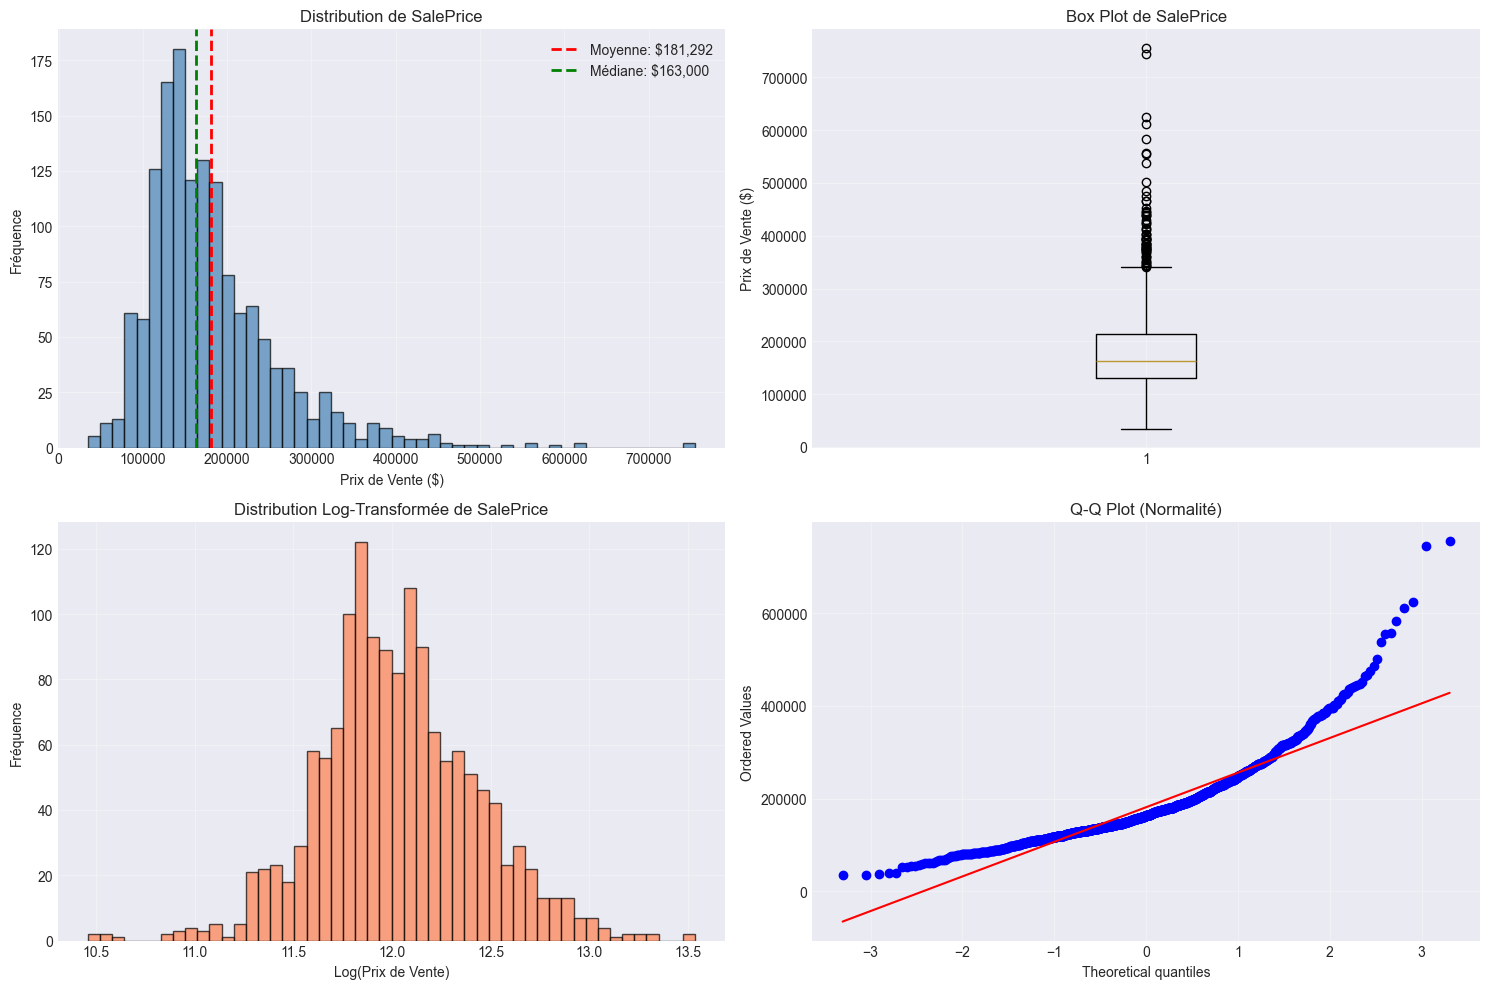


Observation: La distribution est asymetrique a droite
   Une transformation logarithmique peut être bénéfique pour normaliser la distribution.


In [5]:
# Analyse de la variable cible
print("=" * 60)
print("ANALYSE DE LA VARIABLE CIBLE (SalePrice)")
print("=" * 60)

print("\nStatistiques descriptives:")
print(train_df['SalePrice'].describe())

print(f"\nCaracteristiques:")
print(f"   - Minimum: ${train_df['SalePrice'].min():,.2f}")
print(f"   - Maximum: ${train_df['SalePrice'].max():,.2f}")
print(f"   - Moyenne: ${train_df['SalePrice'].mean():,.2f}")
print(f"   - Mediane: ${train_df['SalePrice'].median():,.2f}")
print(f"   - Ecart-type: ${train_df['SalePrice'].std():,.2f}")

print(f"\nDistribution:")
print(f"   - Skewness: {train_df['SalePrice'].skew():.3f} {'(asymétrique à droite)' if train_df['SalePrice'].skew() > 0.5 else '(relativement symétrique)'}")
kurtosis_val = train_df['SalePrice'].kurtosis()
print(f"   - Kurtosis: {kurtosis_val:.3f}")

# Explication du Kurtosis
print(f"\nInterpretation du Kurtosis:")
print(f"   - Kurtosis = 3: Distribution normale (mesokurtique)")
print(f"   - Kurtosis < 3: Distribution avec queues legeres (platikurtique)")
print(f"   - Kurtosis > 3: Distribution avec queues lourdes (leptokurtique)")
print(f"\n   Notre valeur ({kurtosis_val:.3f}) indique:")
if kurtosis_val > 3:
    print(f"   - Distribution LEPTOKURTIQUE (queues tres lourdes)")
    print(f"   - Presence importante de valeurs extremes (outliers)")
    print(f"   - Distribution plus pointue que la normale")
    print(f"   - Necessite une transformation (logarithmique) pour normaliser")
elif kurtosis_val < 3:
    print(f"   - Distribution PLATIKURTIQUE (queues legeres)")
    print(f"   - Moins de valeurs extremes que la normale")
else:
    print(f"   - Distribution MESOKURTIQUE (normale)")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme
axes[0, 0].hist(train_df['SalePrice'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(train_df['SalePrice'].mean(), color='r', linestyle='--', linewidth=2, label=f'Moyenne: ${train_df["SalePrice"].mean():,.0f}')
axes[0, 0].axvline(train_df['SalePrice'].median(), color='g', linestyle='--', linewidth=2, label=f'Médiane: ${train_df["SalePrice"].median():,.0f}')
axes[0, 0].set_xlabel('Prix de Vente ($)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution de SalePrice')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(train_df['SalePrice'], vert=True)
axes[0, 1].set_ylabel('Prix de Vente ($)')
axes[0, 1].set_title('Box Plot de SalePrice')
axes[0, 1].grid(True, alpha=0.3)

# Distribution log-transformée
axes[1, 0].hist(np.log1p(train_df['SalePrice']), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Log(Prix de Vente)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution Log-Transformée de SalePrice')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot pour vérifier la normalité
from scipy import stats
stats.probplot(train_df['SalePrice'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normalité)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/saleprice_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nObservation: La distribution est {'asymetrique a droite' if train_df['SalePrice'].skew() > 0.5 else 'relativement symetrique'}")
print(f"   Une transformation logarithmique peut être bénéfique pour normaliser la distribution.")


In [6]:
# Analyse des valeurs manquantes
print("=" * 60)
print("ANALYSE DES VALEURS MANQUANTES")
print("=" * 60)

missing_train = train_df.isnull().sum()
missing_pct_train = (missing_train / len(train_df)) * 100
missing_df_train = pd.DataFrame({
    'Colonne': missing_train.index,
    'Valeurs_Manquantes': missing_train.values,
    'Pourcentage': missing_pct_train.values
}).sort_values('Valeurs_Manquantes', ascending=False)

missing_df_train = missing_df_train[missing_df_train['Valeurs_Manquantes'] > 0]

print(f"\nColonnes avec valeurs manquantes dans TRAIN: {len(missing_df_train)}")
print(f"\nTop 20 colonnes avec le plus de valeurs manquantes:")
print(missing_df_train.head(20).to_string(index=False))

# Visualisation
if len(missing_df_train) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar plot
    top_missing = missing_df_train.head(15)
    axes[0].barh(range(len(top_missing)), top_missing['Pourcentage'], color='coral')
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing['Colonne'])
    axes[0].set_xlabel('Pourcentage de valeurs manquantes (%)')
    axes[0].set_title('Top 15 Colonnes avec Valeurs Manquantes (Train)')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3)
    
    # Heatmap des valeurs manquantes
    missing_cols = missing_df_train.head(20)['Colonne'].tolist()
    missing_matrix = train_df[missing_cols].isnull()
    sns.heatmap(missing_matrix, yticklabels=False, cbar=True, ax=axes[1], cmap='viridis')
    axes[1].set_title('Pattern des Valeurs Manquantes (Top 20)')
    axes[1].set_xlabel('Colonnes')
    
    plt.tight_layout()
    plt.savefig('../output/figures/missing_values_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nObservations:")
    print(f"   - {len(missing_df_train)} colonnes contiennent des valeurs manquantes")
    print(f"   - La colonne avec le plus de valeurs manquantes: {missing_df_train.iloc[0]['Colonne']} ({missing_df_train.iloc[0]['Pourcentage']:.1f}%)")
else:
    print("\nAucune valeur manquante dans le dataset d'entrainement!")

# Variables sans valeurs manquantes
print("\n" + "=" * 60)
print("VARIABLES SANS VALEURS MANQUANTES")
print("=" * 60)

no_missing = train_df.columns[train_df.isnull().sum() == 0].tolist()
print(f"\nNombre de variables sans valeurs manquantes: {len(no_missing)}")
print(f"Sur un total de {len(train_df.columns)} variables\n")

# Séparer par type
no_missing_numeric = [col for col in no_missing if train_df[col].dtype in ['int64', 'float64']]
no_missing_categorical = [col for col in no_missing if train_df[col].dtype == 'object']

print(f"Variables numeriques sans valeurs manquantes ({len(no_missing_numeric)}):")
for i, col in enumerate(no_missing_numeric, 1):
    print(f"   {i:3d}. {col}")

print(f"\nVariables categorielles sans valeurs manquantes ({len(no_missing_categorical)}):")
for i, col in enumerate(no_missing_categorical, 1):
    print(f"   {i:3d}. {col}")

# Sauvegarder la liste
no_missing_df = pd.DataFrame({
    'Variable': no_missing,
    'Type': ['Numerique' if col in no_missing_numeric else 'Categorielle' for col in no_missing]
})
no_missing_df.to_csv('../output/tables/variables_sans_valeurs_manquantes.csv', index=False)
print(f"\nListe sauvegardee dans: output/tables/variables_sans_valeurs_manquantes.csv")


ANALYSE DES VALEURS MANQUANTES

Colonnes avec valeurs manquantes dans TRAIN: 0

Top 20 colonnes avec le plus de valeurs manquantes:
Empty DataFrame
Columns: [Colonne, Valeurs_Manquantes, Pourcentage]
Index: []

Aucune valeur manquante dans le dataset d'entrainement!

VARIABLES SANS VALEURS MANQUANTES

Nombre de variables sans valeurs manquantes: 81
Sur un total de 81 variables

Variables numeriques sans valeurs manquantes (38):
     1. Id
     2. MSSubClass
     3. LotFrontage
     4. LotArea
     5. OverallQual
     6. OverallCond
     7. YearBuilt
     8. YearRemodAdd
     9. MasVnrArea
    10. BsmtFinSF1
    11. BsmtFinSF2
    12. BsmtUnfSF
    13. TotalBsmtSF
    14. 1stFlrSF
    15. 2ndFlrSF
    16. LowQualFinSF
    17. GrLivArea
    18. BsmtFullBath
    19. BsmtHalfBath
    20. FullBath
    21. HalfBath
    22. BedroomAbvGr
    23. KitchenAbvGr
    24. TotRmsAbvGrd
    25. Fireplaces
    26. GarageYrBlt
    27. GarageCars
    28. GarageArea
    29. WoodDeckSF
    30. OpenPorchSF


In [7]:
# Catégorisation des variables
print("=" * 60)
print("CATÉGORISATION DES VARIABLES")
print("=" * 60)

# Définir les catégories
categories = {
    'Identifiant': ['Id'],
    'Caractéristiques Physiques': [
        'MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'LandContour', 
        'LotConfig', 'LandSlope', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 
        'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd'
    ],
    'Localisation': [
        'MSZoning', 'Street', 'Alley', 'Neighborhood', 'Condition1', 'Condition2'
    ],
    'Type et Style': [
        'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 
        'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea'
    ],
    'Qualité et Condition': [
        'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 
        'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
        'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 
        'Functional', 'FireplaceQu', 'GarageQual', 'GarageCond', 
        'PoolQC', 'Fence'
    ],
    'Sous-sol': [
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
        'BsmtFullBath', 'BsmtHalfBath'
    ],
    'Garage': [
        'GarageType', 'GarageYrBlt', 'GarageFinish', 
        'GarageCars', 'GarageArea'
    ],
    'Salles de bain': [
        'FullBath', 'HalfBath'
    ],
    'Systèmes': [
        'Utilities', 'Heating', 'CentralAir', 'Electrical', 'PavedDrive'
    ],
    'Extérieur': [
        'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 
        '3SsnPorch', 'ScreenPorch', 'PoolArea'
    ],
    'Divers': [
        'Fireplaces', 'MiscFeature', 'MiscVal'
    ],
    'Temporel': [
        'YearBuilt', 'YearRemodAdd', 'MoSold', 'YrSold'
    ],
    'Transaction': [
        'SaleType', 'SaleCondition'
    ],
    'Cible': [
        'SalePrice'
    ]
}

print("\nRepartition des variables par categorie:\n")
for category, vars_list in categories.items():
    existing_vars = [v for v in vars_list if v in train_df.columns]
    if existing_vars:
        print(f"   {category}: {len(existing_vars)} variables")
        print(f"      {', '.join(existing_vars[:5])}")
        if len(existing_vars) > 5:
            print(f"      ... et {len(existing_vars) - 5} autres")
        print()


CATÉGORISATION DES VARIABLES

Repartition des variables par categorie:

   Identifiant: 1 variables
      Id

   Caractéristiques Physiques: 14 variables
      MSSubClass, LotFrontage, LotArea, LotShape, LandContour
      ... et 9 autres

   Localisation: 6 variables
      MSZoning, Street, Alley, Neighborhood, Condition1
      ... et 1 autres

   Type et Style: 8 variables
      BldgType, HouseStyle, RoofStyle, RoofMatl, Exterior1st
      ... et 3 autres

   Qualité et Condition: 18 variables
      OverallQual, OverallCond, ExterQual, ExterCond, Foundation
      ... et 13 autres

   Sous-sol: 6 variables
      BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath
      ... et 1 autres

   Garage: 5 variables
      GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea

   Salles de bain: 2 variables
      FullBath, HalfBath

   Systèmes: 5 variables
      Utilities, Heating, CentralAir, Electrical, PavedDrive

   Extérieur: 6 variables
      WoodDeckSF, OpenPorchSF, Encl

## 6. Variables Numériques Clés


VARIABLES NUMÉRIQUES CLÉS

Statistiques descriptives des variables cles:

       GrLivArea  TotalBsmtSF    LotArea  OverallQual  OverallCond  YearBuilt  \
count    1460.00      1460.00    1460.00      1460.00      1460.00    1460.00   
mean     1515.46      1051.83   10516.83         6.10         5.58    1971.27   
std       525.48       408.25    9981.26         1.38         1.11      30.20   
min       334.00         0.00    1300.00         1.00         1.00    1872.00   
25%      1129.50       795.75    7553.50         5.00         5.00    1954.00   
50%      1464.00       991.50    9478.50         6.00         5.00    1973.00   
75%      1776.75      1298.25   11601.50         7.00         6.00    2000.00   
max      5642.00      2633.00  215245.00        10.00         9.00    2010.00   

       GarageArea  1stFlrSF  FullBath  TotRmsAbvGrd  YearRemodAdd  GarageCars  
count     1460.00   1460.00   1460.00       1460.00       1460.00     1460.00  
mean       472.98   1162.63      1.5

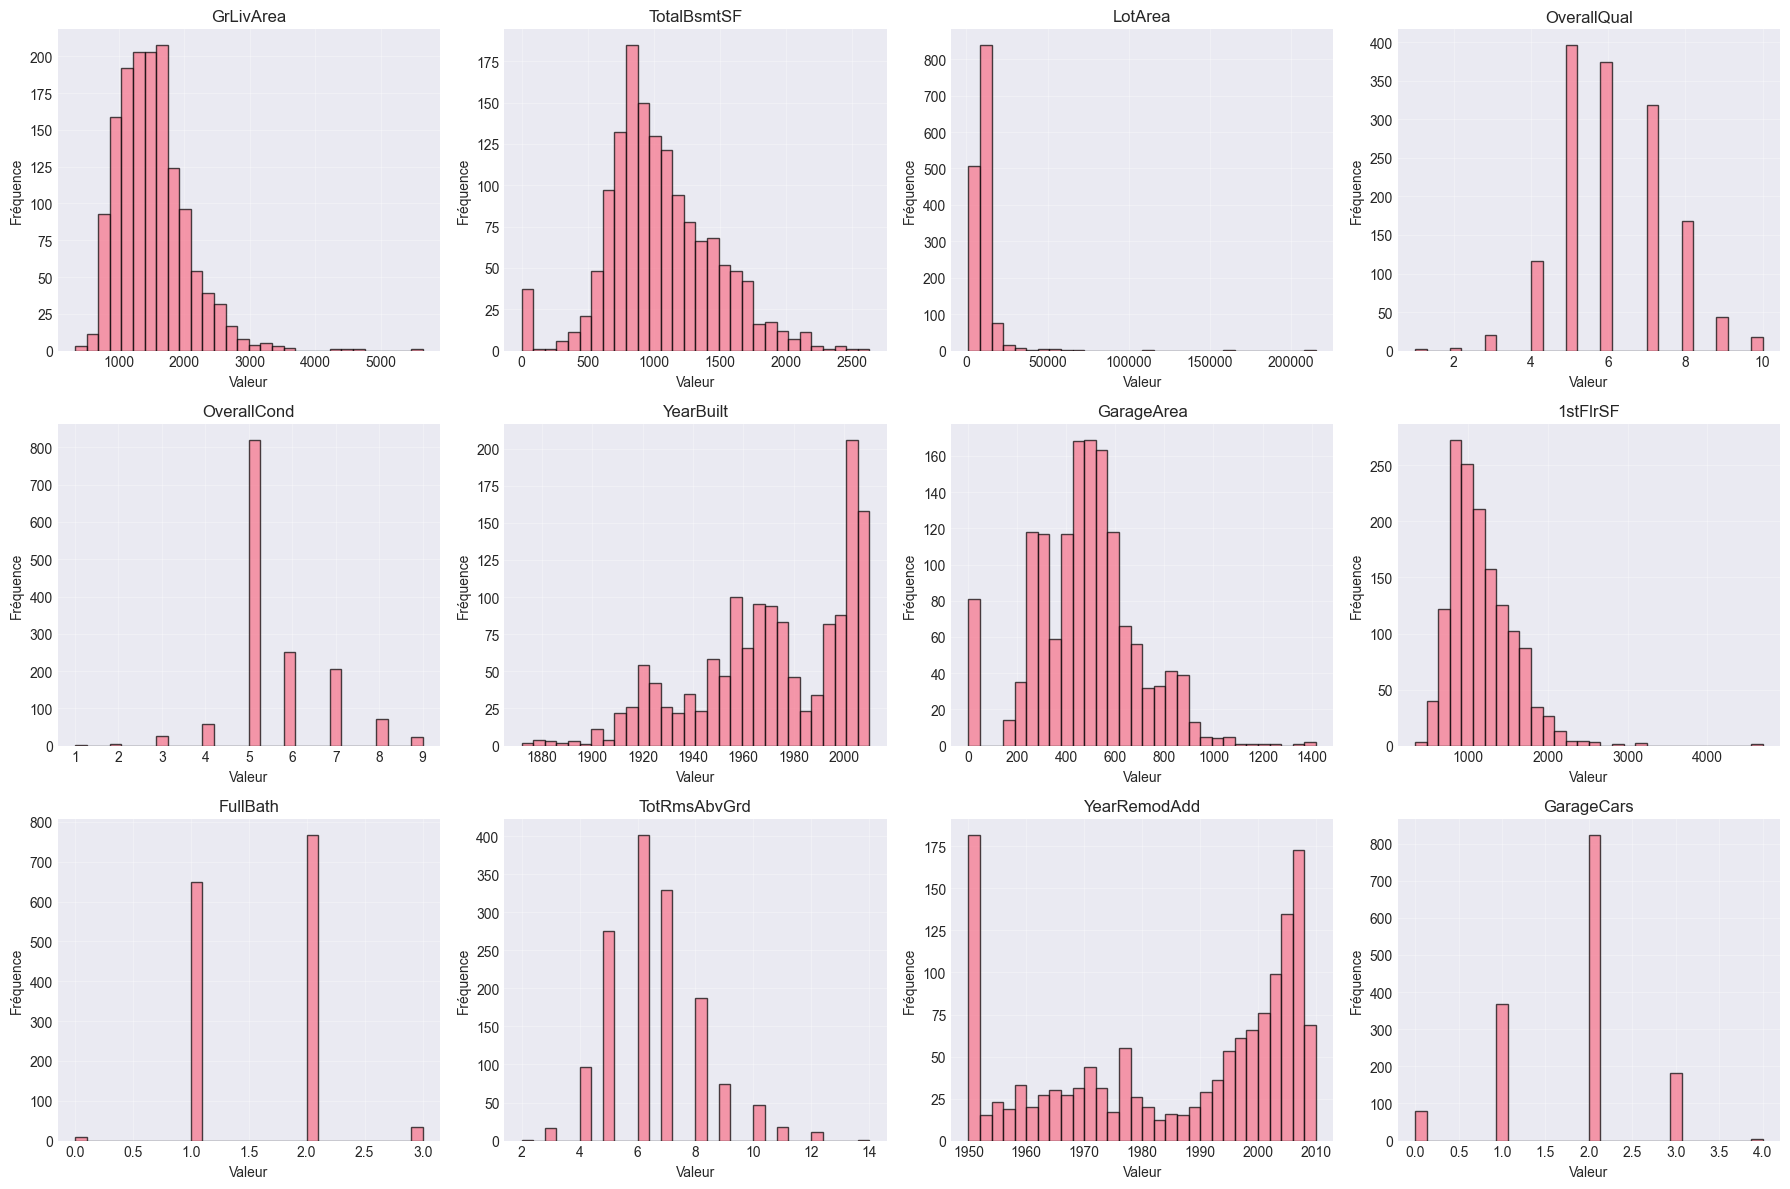

In [8]:
# Analyse des variables numériques importantes
print("=" * 60)
print("VARIABLES NUMÉRIQUES CLÉS")
print("=" * 60)

key_numeric_vars = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'OverallQual', 
                     'OverallCond', 'YearBuilt', 'GarageArea', '1stFlrSF', 
                     'FullBath', 'TotRmsAbvGrd', 'YearRemodAdd', 'GarageCars']

existing_key_vars = [v for v in key_numeric_vars if v in train_df.columns]

print("\nStatistiques descriptives des variables cles:\n")
print(train_df[existing_key_vars].describe().round(2))

# Visualisation des distributions
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, var in enumerate(existing_key_vars[:12]):
    axes[idx].hist(train_df[var].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{var}')
    axes[idx].set_xlabel('Valeur')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/key_numeric_vars_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Variables Catégorielles Clés


VARIABLES CATÉGORIELLES CLÉS

MSZoning:
   Nombre de catégories: 5
   Top 5 valeurs:
      RL: 1151 (78.8%)
      RM: 218 (14.9%)
      FV: 65 (4.5%)
      RH: 16 (1.1%)
      C (all): 10 (0.7%)


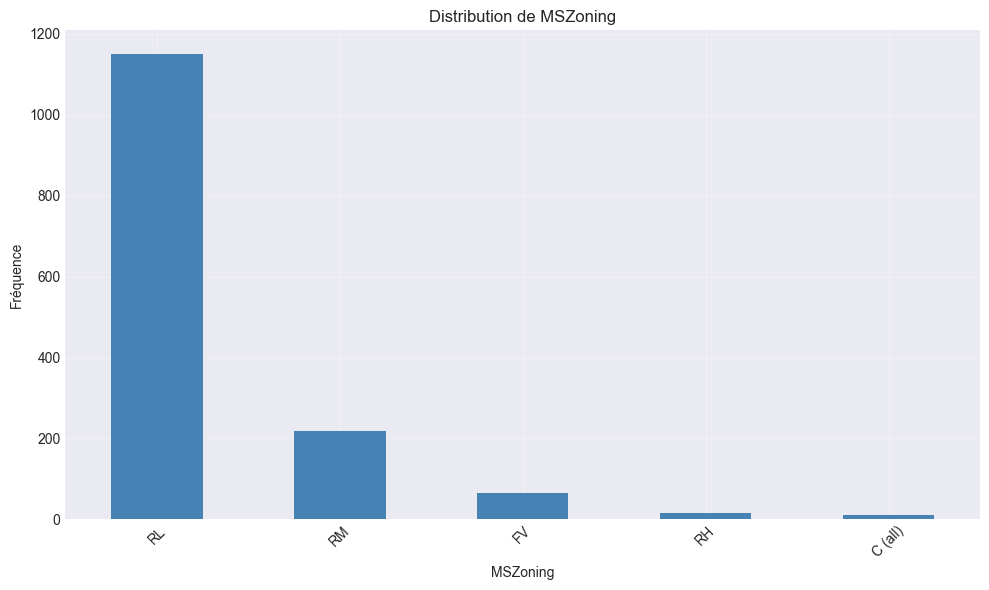


Neighborhood:
   Nombre de catégories: 25
   Top 5 valeurs:
      NAmes: 225 (15.4%)
      CollgCr: 150 (10.3%)
      OldTown: 113 (7.7%)
      Edwards: 100 (6.8%)
      Somerst: 86 (5.9%)

BldgType:
   Nombre de catégories: 5
   Top 5 valeurs:
      1Fam: 1220 (83.6%)
      TwnhsE: 114 (7.8%)
      Duplex: 52 (3.6%)
      Twnhs: 43 (2.9%)
      2fmCon: 31 (2.1%)


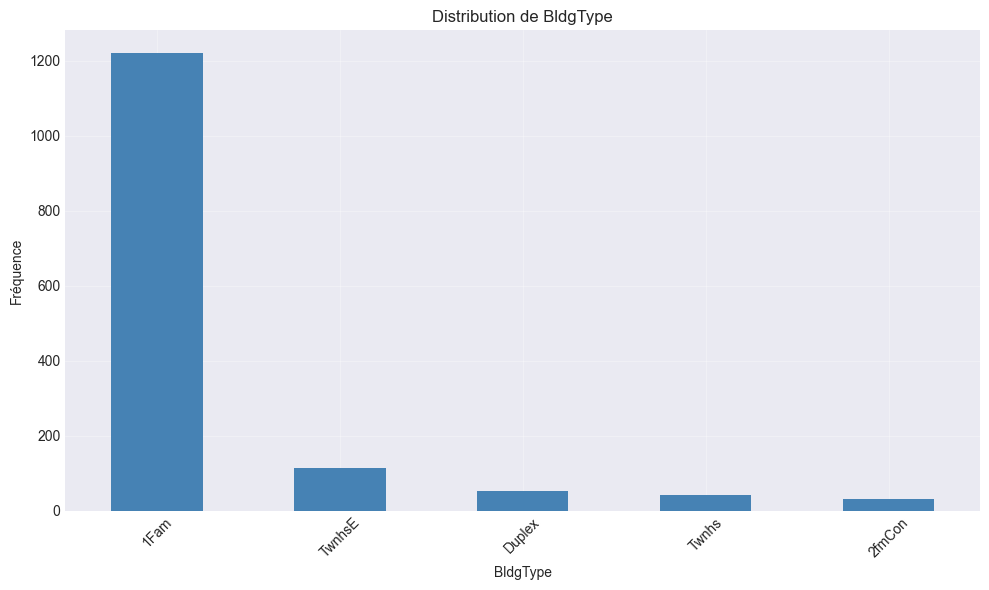


HouseStyle:
   Nombre de catégories: 8
   Top 5 valeurs:
      1Story: 726 (49.7%)
      2Story: 445 (30.5%)
      1.5Fin: 154 (10.5%)
      SLvl: 65 (4.5%)
      SFoyer: 37 (2.5%)


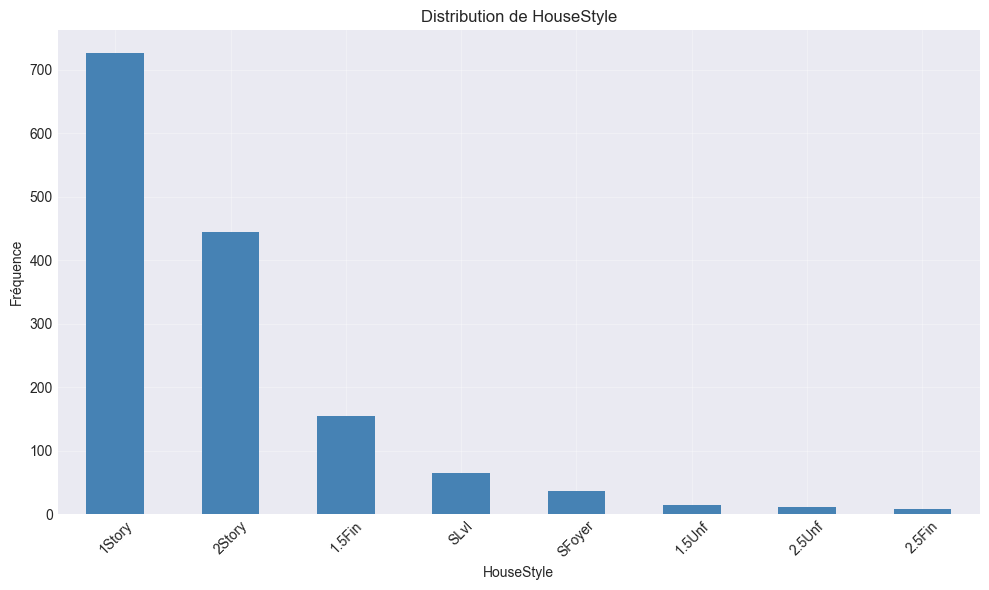


ExterQual:
   Nombre de catégories: 4
   Top 5 valeurs:
      TA: 906 (62.1%)
      Gd: 488 (33.4%)
      Ex: 52 (3.6%)
      Fa: 14 (1.0%)


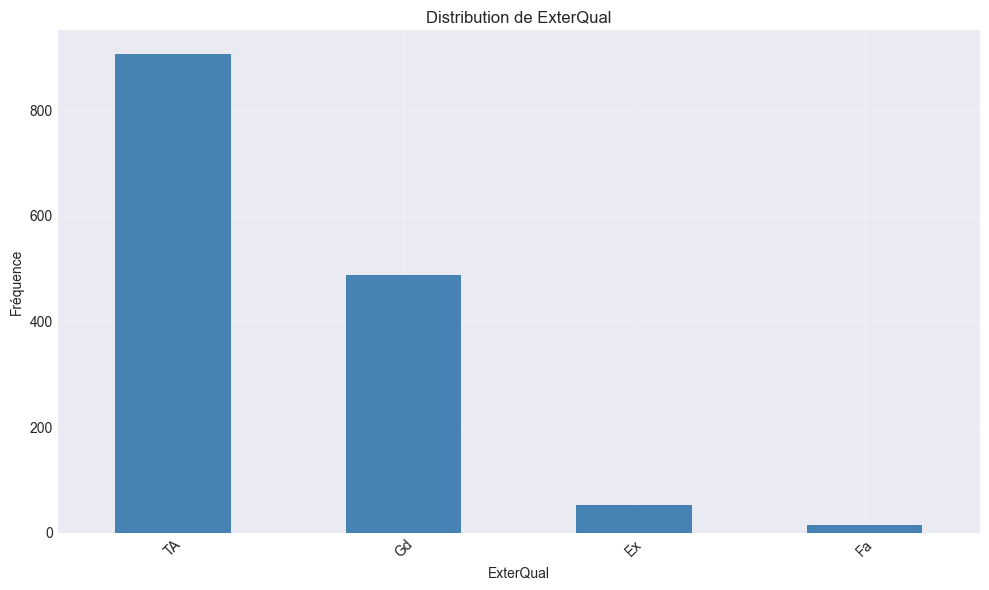


KitchenQual:
   Nombre de catégories: 4
   Top 5 valeurs:
      TA: 735 (50.3%)
      Gd: 586 (40.1%)
      Ex: 100 (6.8%)
      Fa: 39 (2.7%)


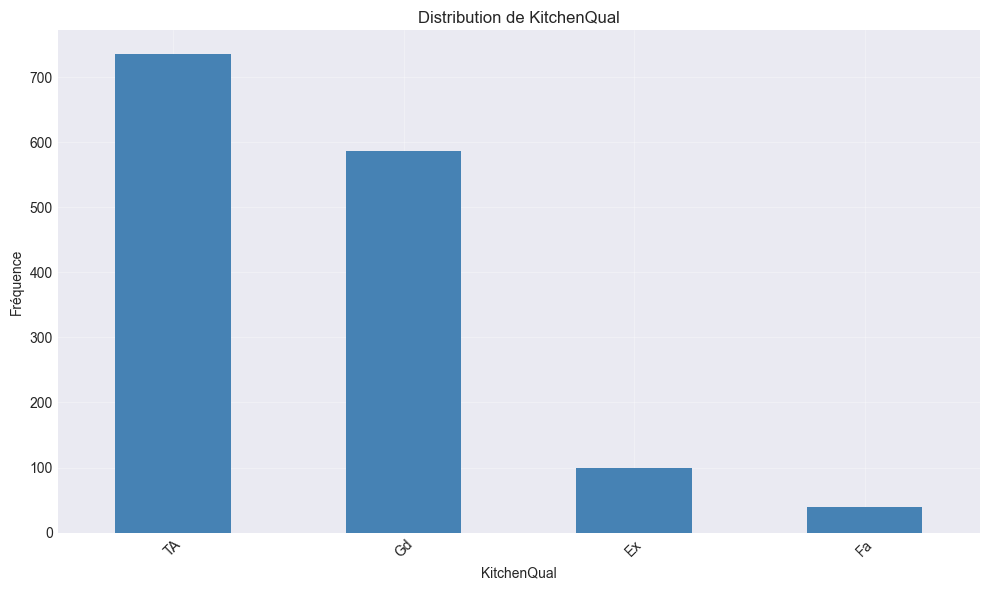


SaleType:
   Nombre de catégories: 9
   Top 5 valeurs:
      WD: 1267 (86.8%)
      New: 122 (8.4%)
      COD: 43 (2.9%)
      ConLD: 9 (0.6%)
      ConLI: 5 (0.3%)


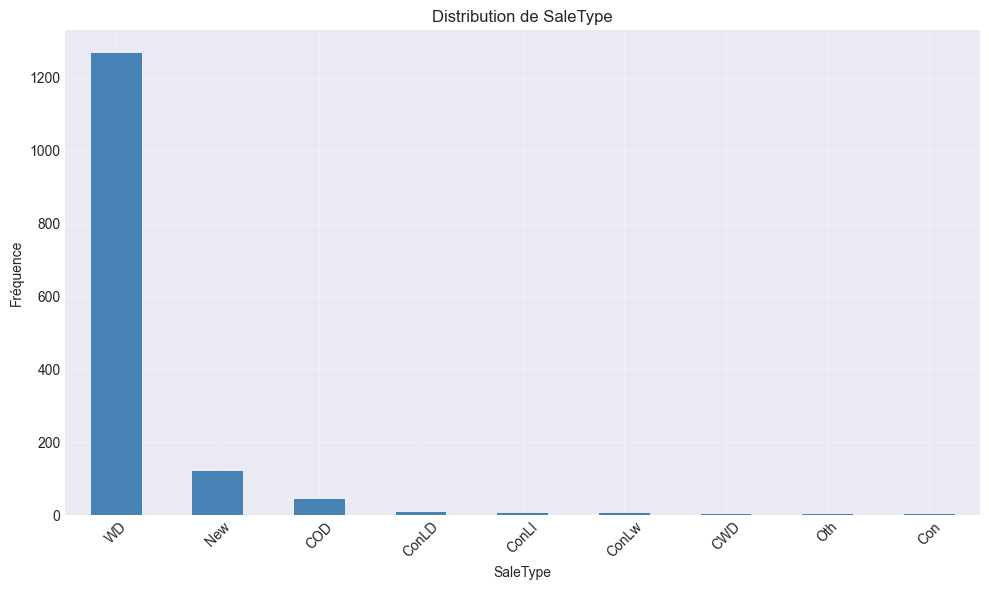


SaleCondition:
   Nombre de catégories: 6
   Top 5 valeurs:
      Normal: 1198 (82.1%)
      Partial: 125 (8.6%)
      Abnorml: 101 (6.9%)
      Family: 20 (1.4%)
      Alloca: 12 (0.8%)


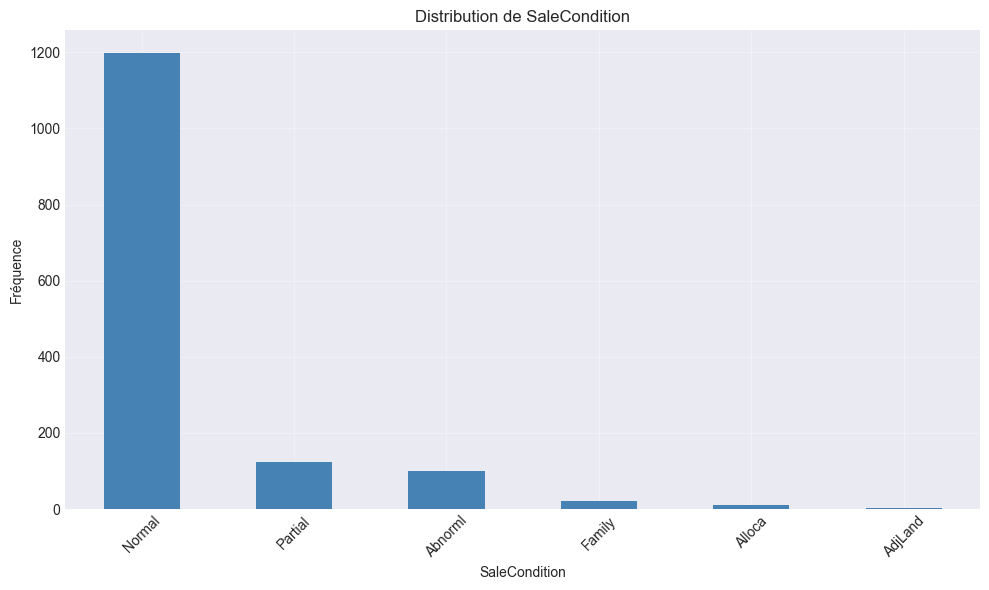

In [9]:
# Analyse des variables catégorielles importantes
print("=" * 60)
print("VARIABLES CATÉGORIELLES CLÉS")
print("=" * 60)

key_categorical_vars = ['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle', 
                        'ExterQual', 'KitchenQual', 'SaleType', 'SaleCondition']

existing_cat_vars = [v for v in key_categorical_vars if v in train_df.columns]

for var in existing_cat_vars:
    print(f"\n{var}:")
    value_counts = train_df[var].value_counts()
    print(f"   Nombre de catégories: {train_df[var].nunique()}")
    print(f"   Top 5 valeurs:")
    for val, count in value_counts.head().items():
        pct = (count / len(train_df)) * 100
        print(f"      {val}: {count} ({pct:.1f}%)")
    
    # Visualisation
    if train_df[var].nunique() <= 20:  # Seulement si pas trop de catégories
        fig, ax = plt.subplots(figsize=(10, 6))
        value_counts.head(10).plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Distribution de {var}')
        ax.set_xlabel(var)
        ax.set_ylabel('Fréquence')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'../output/figures/categorical_{var}.png', dpi=300, bbox_inches='tight')
        plt.show()


## 8. Corrélations avec la Variable Cible


CORRÉLATIONS AVEC SALEPRICE

Top 20 variables les plus correlees avec SalePrice:

   OverallQual         :  0.798 (forte)
   GrLivArea           :  0.736 (forte)
   TotalBsmtSF         :  0.653 (forte)
   GarageCars          :  0.640 (forte)
   1stFlrSF            :  0.635 (forte)
   GarageArea          :  0.634 (forte)
   FullBath            :  0.564 (forte)
   TotRmsAbvGrd        :  0.544 (forte)
   YearBuilt           :  0.525 (forte)
   YearRemodAdd        :  0.509 (forte)
   MasVnrArea          :  0.487 (moderee)
   Fireplaces          :  0.474 (moderee)
   BsmtFinSF1          :  0.420 (moderee)
   LotFrontage         :  0.380 (moderee)
   OpenPorchSF         :  0.335 (moderee)
   2ndFlrSF            :  0.326 (moderee)
   WoodDeckSF          :  0.326 (moderee)
   HalfBath            :  0.288 (faible)
   LotArea             :  0.281 (faible)

Bottom 10 variables les moins correlees avec SalePrice:

   3SsnPorch           :  0.044
   BsmtFinSF2          : -0.013
   BsmtHalfBath     

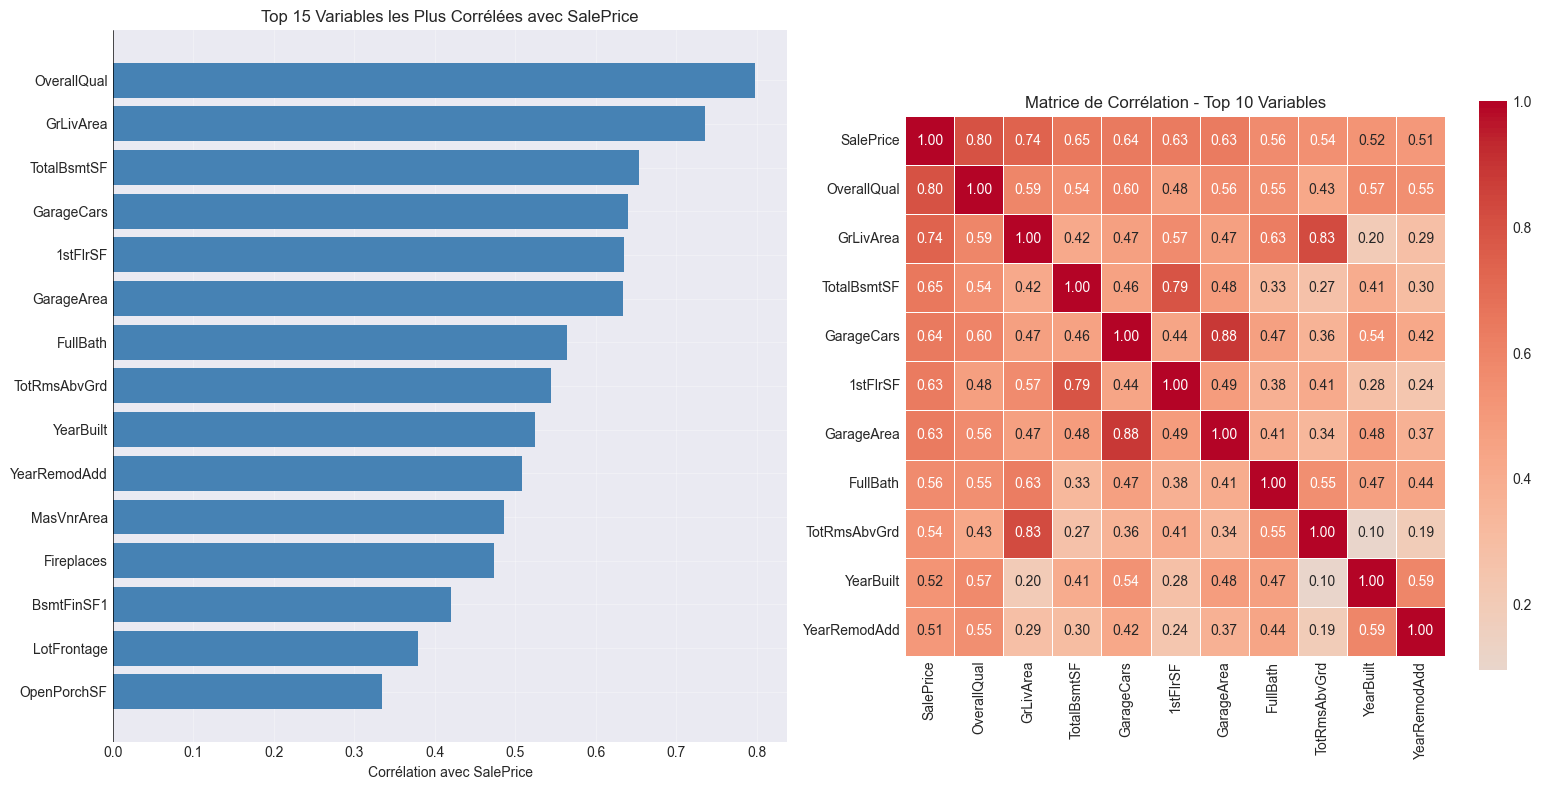


Observations:
   - Variable la plus corrélée: OverallQual (0.798)
   - 10 variables ont une corrélation forte (|r| > 0.5) avec SalePrice
   - 17 variables ont une corrélation modérée (|r| > 0.3) avec SalePrice


In [10]:
# Corrélations avec SalePrice
print("=" * 60)
print("CORRÉLATIONS AVEC SALEPRICE")
print("=" * 60)

# Calculer les corrélations
correlations = train_df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

print("\nTop 20 variables les plus correlees avec SalePrice:\n")
top_corr = correlations.head(20)
for var, corr in top_corr.items():
    if var != 'SalePrice':
        print(f"   {var:20s}: {corr:6.3f} {'(forte)' if abs(corr) > 0.5 else '(moderee)' if abs(corr) > 0.3 else '(faible)'}")

print("\nBottom 10 variables les moins correlees avec SalePrice:\n")
bottom_corr = correlations.tail(11)  # 11 car SalePrice est inclus
for var, corr in bottom_corr.items():
    if var != 'SalePrice':
        print(f"   {var:20s}: {corr:6.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top corrélations
top_15 = correlations.head(16).drop('SalePrice')  # Exclure SalePrice
axes[0].barh(range(len(top_15)), top_15.values, color='steelblue')
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15.index)
axes[0].set_xlabel('Corrélation avec SalePrice')
axes[0].set_title('Top 15 Variables les Plus Corrélées avec SalePrice')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Matrice de corrélation des top variables
top_corr_vars = correlations.head(11).index.tolist()  # Top 10 + SalePrice
corr_matrix = train_df[top_corr_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title('Matrice de Corrélation - Top 10 Variables')

plt.tight_layout()
plt.savefig('../output/figures/correlations_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nObservations:")
print(f"   - Variable la plus corrélée: {correlations.drop('SalePrice').index[0]} ({correlations.drop('SalePrice').iloc[0]:.3f})")
print(f"   - {len(correlations[abs(correlations) > 0.5]) - 1} variables ont une corrélation forte (|r| > 0.5) avec SalePrice")
print(f"   - {len(correlations[abs(correlations) > 0.3]) - 1} variables ont une corrélation modérée (|r| > 0.3) avec SalePrice")


## 9. Détection des Outliers


DÉTECTION DES OUTLIERS

Outliers detectes (methode IQR):

   GrLivArea: 31 outliers (2.12%)
   TotalBsmtSF: 60 outliers (4.11%)
   LotArea: 69 outliers (4.73%)
   SalePrice: 63 outliers (4.32%)

   Variable  Outliers Pourcentage Limite Inf Limite Sup
  GrLivArea        31       2.12%     158.62    2747.62
TotalBsmtSF        60       4.11%      42.00    2052.00
    LotArea        69       4.73%    1481.50   17673.50
  SalePrice        63       4.32%    3937.50  340037.50


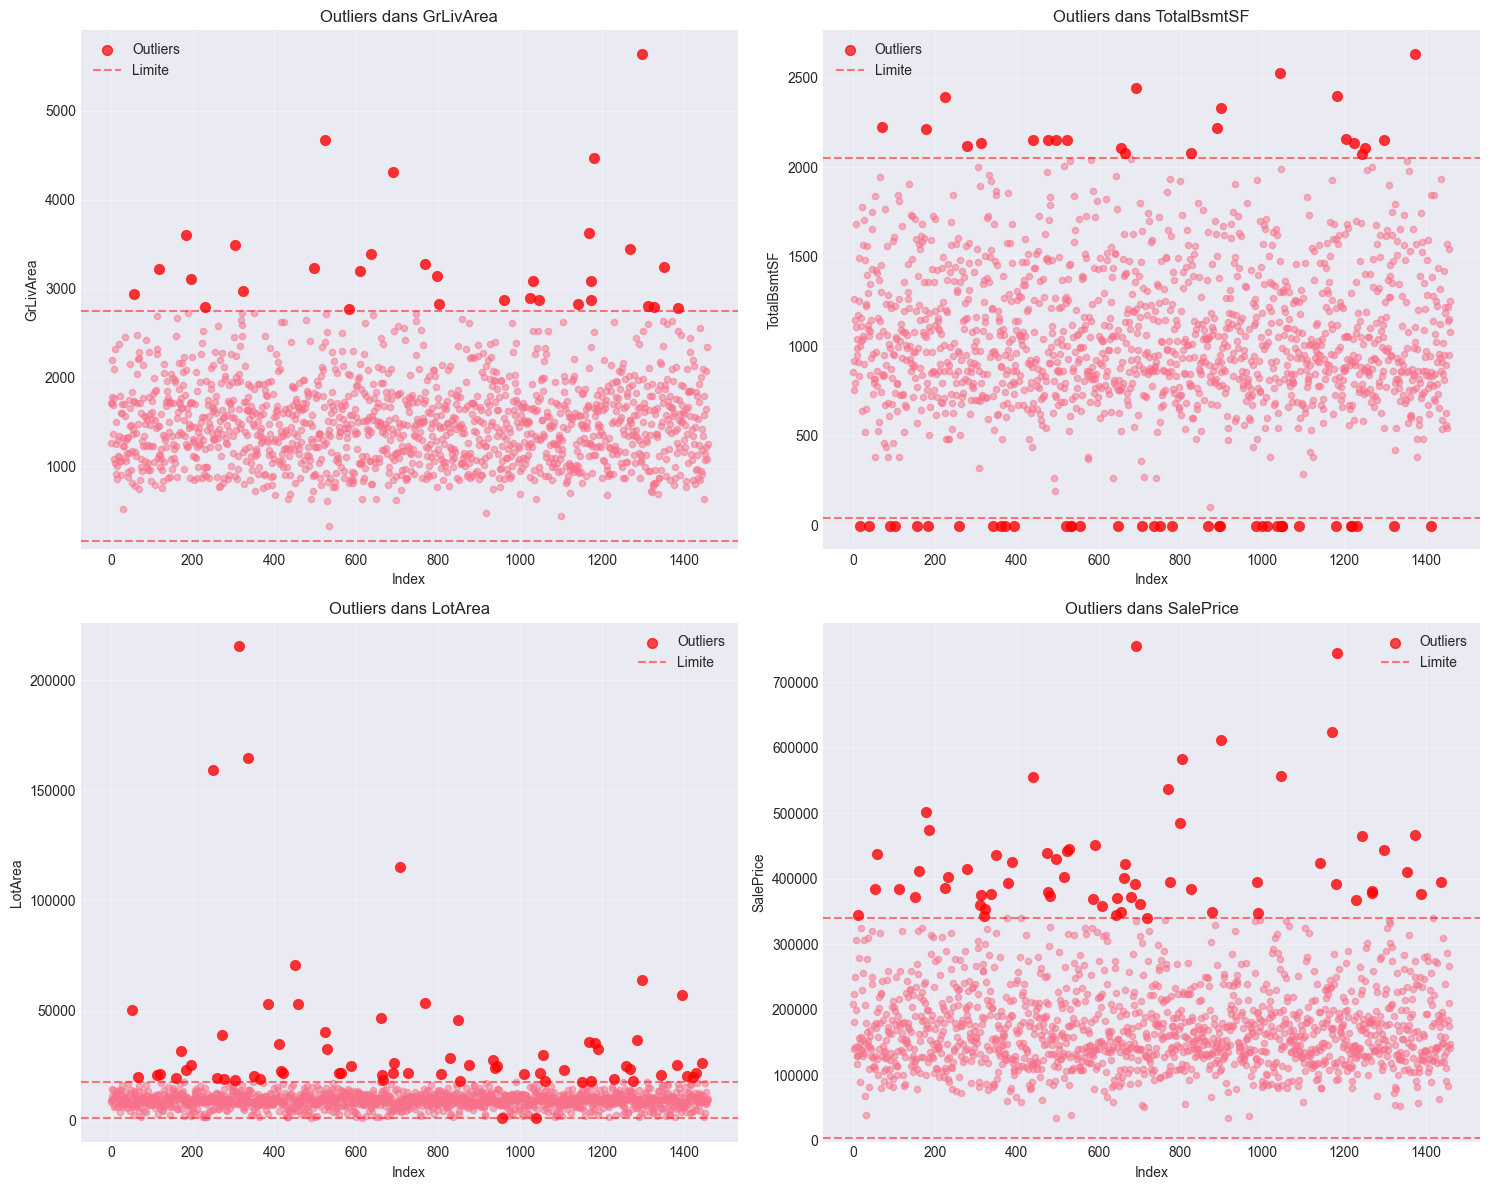


Analyse specifique: GrLivArea vs SalePrice


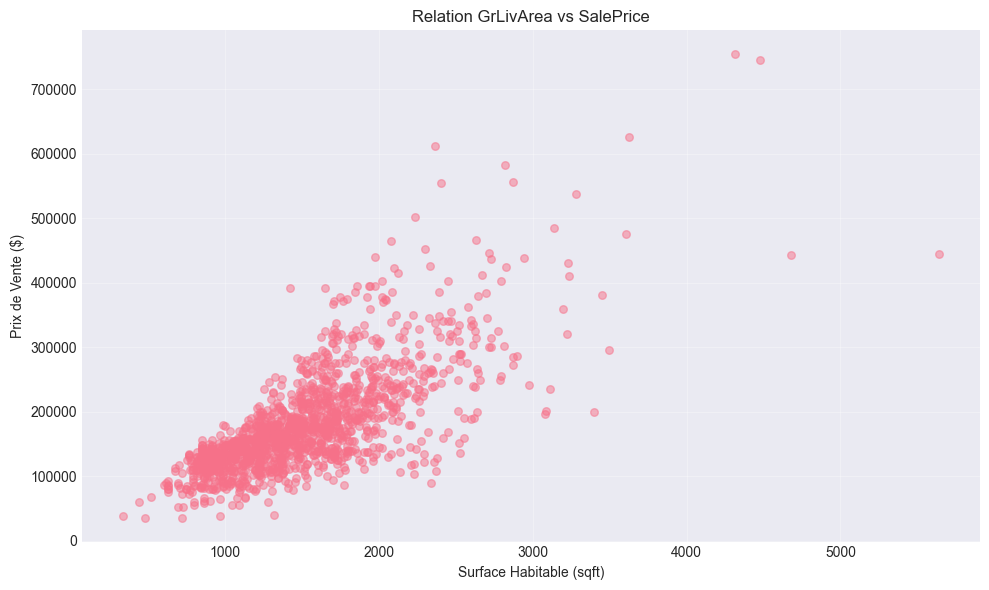

In [11]:
# Détection des outliers
print("=" * 60)
print("DÉTECTION DES OUTLIERS")
print("=" * 60)

# Méthode IQR pour les variables numériques clés
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

key_vars_for_outliers = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'SalePrice']

print("\nOutliers detectes (methode IQR):\n")
outliers_summary = []

for var in key_vars_for_outliers:
    if var in train_df.columns:
        outliers, lower, upper = detect_outliers_iqr(train_df, var)
        pct = (len(outliers) / len(train_df)) * 100
        outliers_summary.append({
            'Variable': var,
            'Outliers': len(outliers),
            'Pourcentage': f'{pct:.2f}%',
            'Limite Inf': f'{lower:.2f}',
            'Limite Sup': f'{upper:.2f}'
        })
        print(f"   {var}: {len(outliers)} outliers ({pct:.2f}%)")

outliers_df = pd.DataFrame(outliers_summary)
print("\n" + outliers_df.to_string(index=False))

# Visualisation des outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for idx, var in enumerate(key_vars_for_outliers):
    if var in train_df.columns:
        row = idx // 2
        col = idx % 2
        
        # Scatter plot avec outliers
        axes[row, col].scatter(train_df.index, train_df[var], alpha=0.5, s=20)
        
        # Identifier et marquer les outliers
        outliers, lower, upper = detect_outliers_iqr(train_df, var)
        if len(outliers) > 0:
            axes[row, col].scatter(outliers.index, outliers[var], 
                                  color='red', s=50, alpha=0.7, label='Outliers')
            axes[row, col].axhline(y=upper, color='r', linestyle='--', alpha=0.5, label='Limite')
            axes[row, col].axhline(y=lower, color='r', linestyle='--', alpha=0.5)
        
        axes[row, col].set_xlabel('Index')
        axes[row, col].set_ylabel(var)
        axes[row, col].set_title(f'Outliers dans {var}')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/outliers_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# Outliers spécifiques pour GrLivArea vs SalePrice
if 'GrLivArea' in train_df.columns and 'SalePrice' in train_df.columns:
    print("\nAnalyse specifique: GrLivArea vs SalePrice")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5, s=30)
    
    # Identifier les outliers (grande surface mais prix bas)
    outliers_grliv = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
    if len(outliers_grliv) > 0:
        ax.scatter(outliers_grliv['GrLivArea'], outliers_grliv['SalePrice'], 
                  color='red', s=100, alpha=0.7, label='Outliers suspects')
        print(f"   Maisons avec GrLivArea > 4000 et SalePrice < 300000: {len(outliers_grliv)}")
    
    ax.set_xlabel('Surface Habitable (sqft)')
    ax.set_ylabel('Prix de Vente ($)')
    ax.set_title('Relation GrLivArea vs SalePrice')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../output/figures/grlivarea_vs_saleprice.png', dpi=300, bbox_inches='tight')
    plt.show()


## 10. Relations entre Variables Clés et Prix


RELATIONS VARIABLES CLÉS vs PRIX


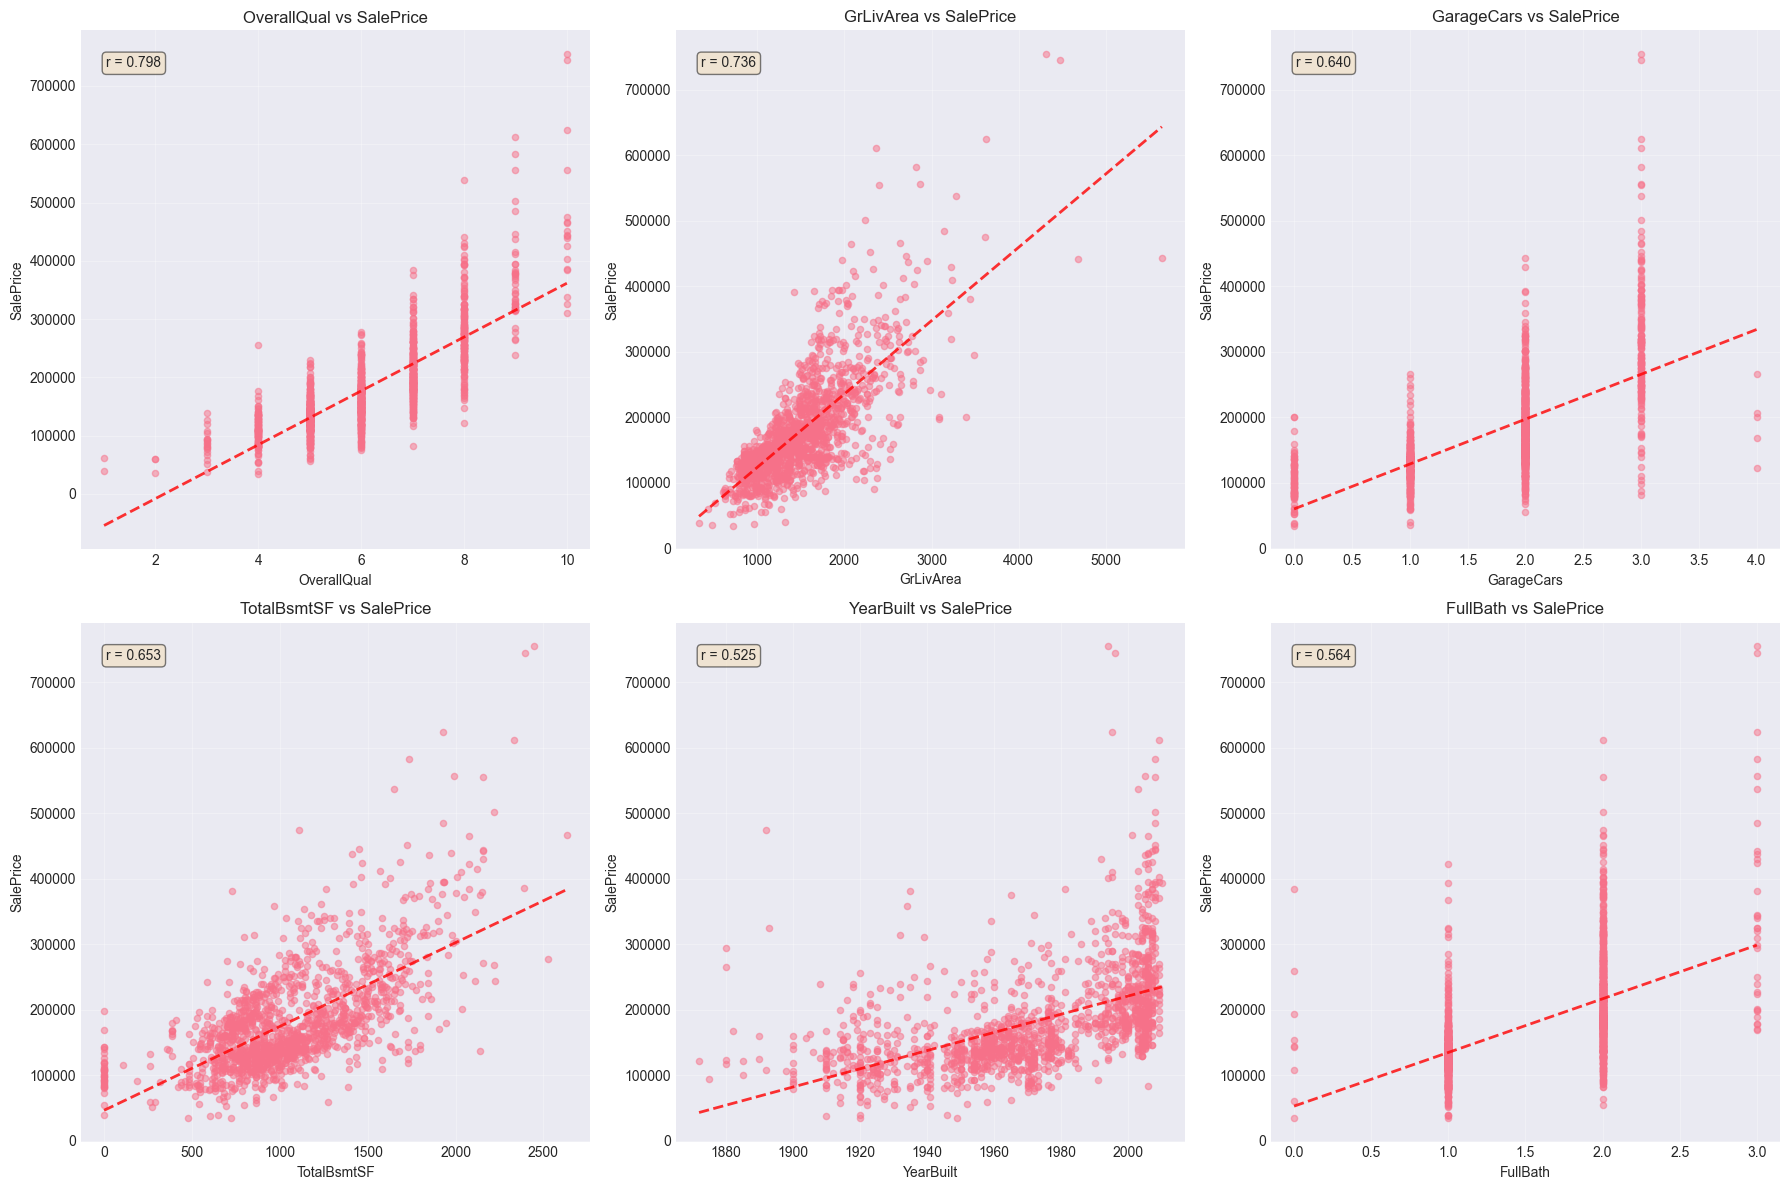

In [12]:
# Analyse des relations entre variables clés et prix
print("=" * 60)
print("RELATIONS VARIABLES CLÉS vs PRIX")
print("=" * 60)

# Variables à analyser
key_analysis_vars = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 
                     'YearBuilt', 'FullBath']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, var in enumerate(key_analysis_vars):
    if var in train_df.columns:
        if train_df[var].dtype in ['int64', 'float64']:
            # Scatter plot pour variables numériques
            axes[idx].scatter(train_df[var], train_df['SalePrice'], alpha=0.5, s=20)
            axes[idx].set_xlabel(var)
            axes[idx].set_ylabel('SalePrice')
            axes[idx].set_title(f'{var} vs SalePrice')
            
            # Ajouter une ligne de tendance
            z = np.polyfit(train_df[var].dropna(), train_df.loc[train_df[var].notna(), 'SalePrice'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(train_df[var].min(), train_df[var].max(), 100)
            axes[idx].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
            
            # Calculer la corrélation
            corr = train_df[[var, 'SalePrice']].corr().iloc[0, 1]
            axes[idx].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[idx].transAxes,
                          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            # Box plot pour variables catégorielles
            categories = train_df[var].value_counts().head(10).index
            data_to_plot = [train_df[train_df[var] == cat]['SalePrice'].values for cat in categories]
            axes[idx].boxplot(data_to_plot, labels=categories)
            axes[idx].set_xlabel(var)
            axes[idx].set_ylabel('SalePrice')
            axes[idx].set_title(f'{var} vs SalePrice')
            axes[idx].tick_params(axis='x', rotation=45)
        
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/key_vars_vs_price.png', dpi=300, bbox_inches='tight')
plt.show()


## 11. Résumé et Conclusions

### Points Clés à Retenir:

1. **Structure du Dataset**:
   - 1460 observations d'entraînement
   - 80 variables explicatives + 1 variable cible (SalePrice)
   - Mix de variables numériques et catégorielles

2. **Variable Cible**:
   - Distribution asymétrique à droite
   - Nécessite une transformation logarithmique
   - Prix moyen: ~$180,000

3. **Variables les Plus Importantes**:
   - OverallQual (qualité globale)
   - GrLivArea (surface habitable)
   - GarageCars (taille du garage)
   - TotalBsmtSF (surface du sous-sol)

4. **Valeurs Manquantes**:
   - Plusieurs colonnes contiennent des valeurs manquantes
   - Nécessite un traitement approprié

5. **Outliers**:
   - Présence d'outliers dans certaines variables
   - Nécessite une analyse et un traitement

### Prochaines Étapes:

- Nettoyage des données
- Traitement des valeurs manquantes
- Feature engineering
- Modélisation


## 12. Traitement des Valeurs Aberrantes (Outliers)


In [13]:
# Traitement des valeurs aberrantes
print("=" * 60)
print("TRAITEMENT DES VALEURS ABERRANTES")
print("=" * 60)

# Copie des données pour le traitement
train_processed = train_df.copy()

# Fonction pour détecter et traiter les outliers Type 1: GrLivArea > 4000 et SalePrice < 300000
def treat_outliers_type1(df):
    """Traiter les outliers Type 1: grande surface mais prix bas."""
    outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].copy()
    
    if len(outliers) == 0:
        print("Aucun outlier Type 1 détecté.")
        return df
    
    print(f"\nType 1: GrLivArea > 4000 et SalePrice < 300000")
    print(f"Nombre d'outliers détectés: {len(outliers)}")
    
    for idx in outliers.index:
        # Trouver des maisons similaires
        neighborhood = df.loc[idx, 'Neighborhood']
        overall_qual = df.loc[idx, 'OverallQual']
        grlivarea = df.loc[idx, 'GrLivArea']
        
        # Maisons similaires: même quartier, qualité similaire (±1), surface proche (±20%)
        similar = df[
            (df['Neighborhood'] == neighborhood) &
            (df['OverallQual'] >= overall_qual - 1) &
            (df['OverallQual'] <= overall_qual + 1) &
            (df['GrLivArea'] >= grlivarea * 0.8) &
            (df['GrLivArea'] <= grlivarea * 1.2) &
            (df.index != idx)
        ]
        
        if len(similar) > 5:
            # Calculer la régression log-linéaire
            log_price = np.log1p(similar['SalePrice'])
            log_area = np.log1p(similar['GrLivArea'])
            
            # Régression simple
            slope = np.cov(log_price, log_area)[0, 1] / np.var(log_area)
            intercept = log_price.mean() - slope * log_area.mean()
            
            # Ajuster le prix
            log_area_outlier = np.log1p(grlivarea)
            log_price_adjusted = intercept + slope * log_area_outlier
            price_adjusted = np.expm1(log_price_adjusted)
            
            # Limiter au percentile 99 pour sécurité
            p99_price = df['SalePrice'].quantile(0.99)
            price_adjusted = min(price_adjusted, p99_price)
            
            old_price = df.loc[idx, 'SalePrice']
            df.loc[idx, 'SalePrice'] = price_adjusted
            
            print(f"  Index {idx}: Prix ajusté de ${old_price:,.0f} à ${price_adjusted:,.0f}")
        else:
            # Fallback: capping au percentile 99
            p99_price = df['SalePrice'].quantile(0.99)
            old_price = df.loc[idx, 'SalePrice']
            df.loc[idx, 'SalePrice'] = min(old_price * 1.2, p99_price)
            print(f"  Index {idx}: Prix ajusté (fallback) de ${old_price:,.0f} à ${df.loc[idx, 'SalePrice']:,.0f}")
    
    return df

# Fonction pour traiter les outliers Type 2: TotalBsmtSF >= 3000
def treat_outliers_type2(df):
    """Traiter les outliers Type 2: sous-sol très grand."""
    outliers = df[df['TotalBsmtSF'] >= 3000].copy()
    
    if len(outliers) == 0:
        print("\nAucun outlier Type 2 détecté.")
        return df
    
    print(f"\nType 2: TotalBsmtSF >= 3000")
    print(f"Nombre d'outliers détectés: {len(outliers)}")
    
    p99_bsmt = df['TotalBsmtSF'].quantile(0.99)
    
    for idx in outliers.index:
        total_bsmt = df.loc[idx, 'TotalBsmtSF']
        grlivarea = df.loc[idx, 'GrLivArea']
        
        # Vérifier la cohérence avec GrLivArea
        ratio = total_bsmt / grlivarea if grlivarea > 0 else 0
        
        if ratio > 1.5:  # Incohérent
            new_value = min(p99_bsmt, grlivarea * 1.2)
        else:  # Cohérent mais extrême
            new_value = p99_bsmt
        
        old_value = df.loc[idx, 'TotalBsmtSF']
        df.loc[idx, 'TotalBsmtSF'] = new_value
        print(f"  Index {idx}: TotalBsmtSF ajusté de {old_value:.0f} à {new_value:.0f}")
    
    return df

# Appliquer les traitements sur les données d'entraînement
print(f"\n{'='*60}")
print("TRAITEMENT DES DONNÉES D'ENTRAÎNEMENT")
print(f"{'='*60}")
print(f"Observations avant traitement: {len(train_processed)}")
train_processed = treat_outliers_type1(train_processed)
train_processed = treat_outliers_type2(train_processed)
print(f"Observations après traitement: {len(train_processed)}")
print("Aucune observation supprimée - transformation contextuelle appliquée.")

# Traitement des données de test
print(f"\n{'='*60}")
print("TRAITEMENT DES DONNÉES DE TEST")
print(f"{'='*60}")

# Copie des données de test pour le traitement
test_processed = test_df.copy()

# Note: Pour les données de test, on ne peut traiter que les outliers Type 2
# car il n'y a pas de variable SalePrice dans le test set
print(f"Observations avant traitement: {len(test_processed)}")

# Traiter les outliers Type 2 pour les données de test
# Utiliser les percentiles du train pour la cohérence
p99_bsmt_train = train_processed['TotalBsmtSF'].quantile(0.99) if 'TotalBsmtSF' in train_processed.columns else 3000

if 'TotalBsmtSF' in test_processed.columns:
    outliers_test = test_processed[test_processed['TotalBsmtSF'] >= 3000].copy()
    
    if len(outliers_test) > 0:
        print(f"\nType 2: TotalBsmtSF >= 3000")
        print(f"Nombre d'outliers détectés dans le test: {len(outliers_test)}")
        
        for idx in outliers_test.index:
            total_bsmt = test_processed.loc[idx, 'TotalBsmtSF']
            grlivarea = test_processed.loc[idx, 'GrLivArea'] if 'GrLivArea' in test_processed.columns else 0
            
            # Vérifier la cohérence avec GrLivArea
            ratio = total_bsmt / grlivarea if grlivarea > 0 else 0
            
            if ratio > 1.5:  # Incohérent
                new_value = min(p99_bsmt_train, grlivarea * 1.2)
            else:  # Cohérent mais extrême
                new_value = p99_bsmt_train
            
            old_value = test_processed.loc[idx, 'TotalBsmtSF']
            test_processed.loc[idx, 'TotalBsmtSF'] = new_value
            print(f"  Index {idx}: TotalBsmtSF ajusté de {old_value:.0f} à {new_value:.0f}")
    else:
        print("\nAucun outlier Type 2 détecté dans les données de test.")
else:
    print("\nColonne TotalBsmtSF absente des données de test.")

print(f"Observations après traitement: {len(test_processed)}")
print("Aucune observation supprimée - transformation contextuelle appliquée.")

# Sauvegarder les données traitées
print(f"\n{'='*60}")
print("SAUVEGARDE DES DONNÉES TRAITÉES")
print(f"{'='*60}")

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

train_outliers_path = output_dir / "train_outliers_treated.csv"
test_outliers_path = output_dir / "test_outliers_treated.csv"

train_processed.to_csv(train_outliers_path, index=False)
test_processed.to_csv(test_outliers_path, index=False)

print(f"\nDonnées sauvegardées:")
print(f"   - Train: {train_outliers_path}")
print(f"   - Test: {test_outliers_path}")
print(f"\nForme des données:")
print(f"   - Train: {train_processed.shape}")
print(f"   - Test: {test_processed.shape}")


TRAITEMENT DES VALEURS ABERRANTES

TRAITEMENT DES DONNÉES D'ENTRAÎNEMENT
Observations avant traitement: 1460
Aucun outlier Type 1 détecté.

Aucun outlier Type 2 détecté.
Observations après traitement: 1460
Aucune observation supprimée - transformation contextuelle appliquée.

TRAITEMENT DES DONNÉES DE TEST
Observations avant traitement: 1459

Type 2: TotalBsmtSF >= 3000
Nombre d'outliers détectés dans le test: 1
  Index 1089: TotalBsmtSF ajusté de 5095 à 2143
Observations après traitement: 1459
Aucune observation supprimée - transformation contextuelle appliquée.

SAUVEGARDE DES DONNÉES TRAITÉES

Données sauvegardées:
   - Train: ..\data\processed\train_outliers_treated.csv
   - Test: ..\data\processed\test_outliers_treated.csv

Forme des données:
   - Train: (1460, 81)
   - Test: (1459, 80)


## 13. Transformation de la Variable Cible (SalePrice)


TRANSFORMATION DE LA VARIABLE CIBLE (SalePrice)

Avant transformation:
   Skewness: 1.876
   Kurtosis: 6.382
   Moyenne: $181,292.36
   Médiane: $163,000.00

Après transformation log1p:
   Skewness: 0.130
   Kurtosis: 0.795
   Moyenne: 12.025
   Médiane: 12.002


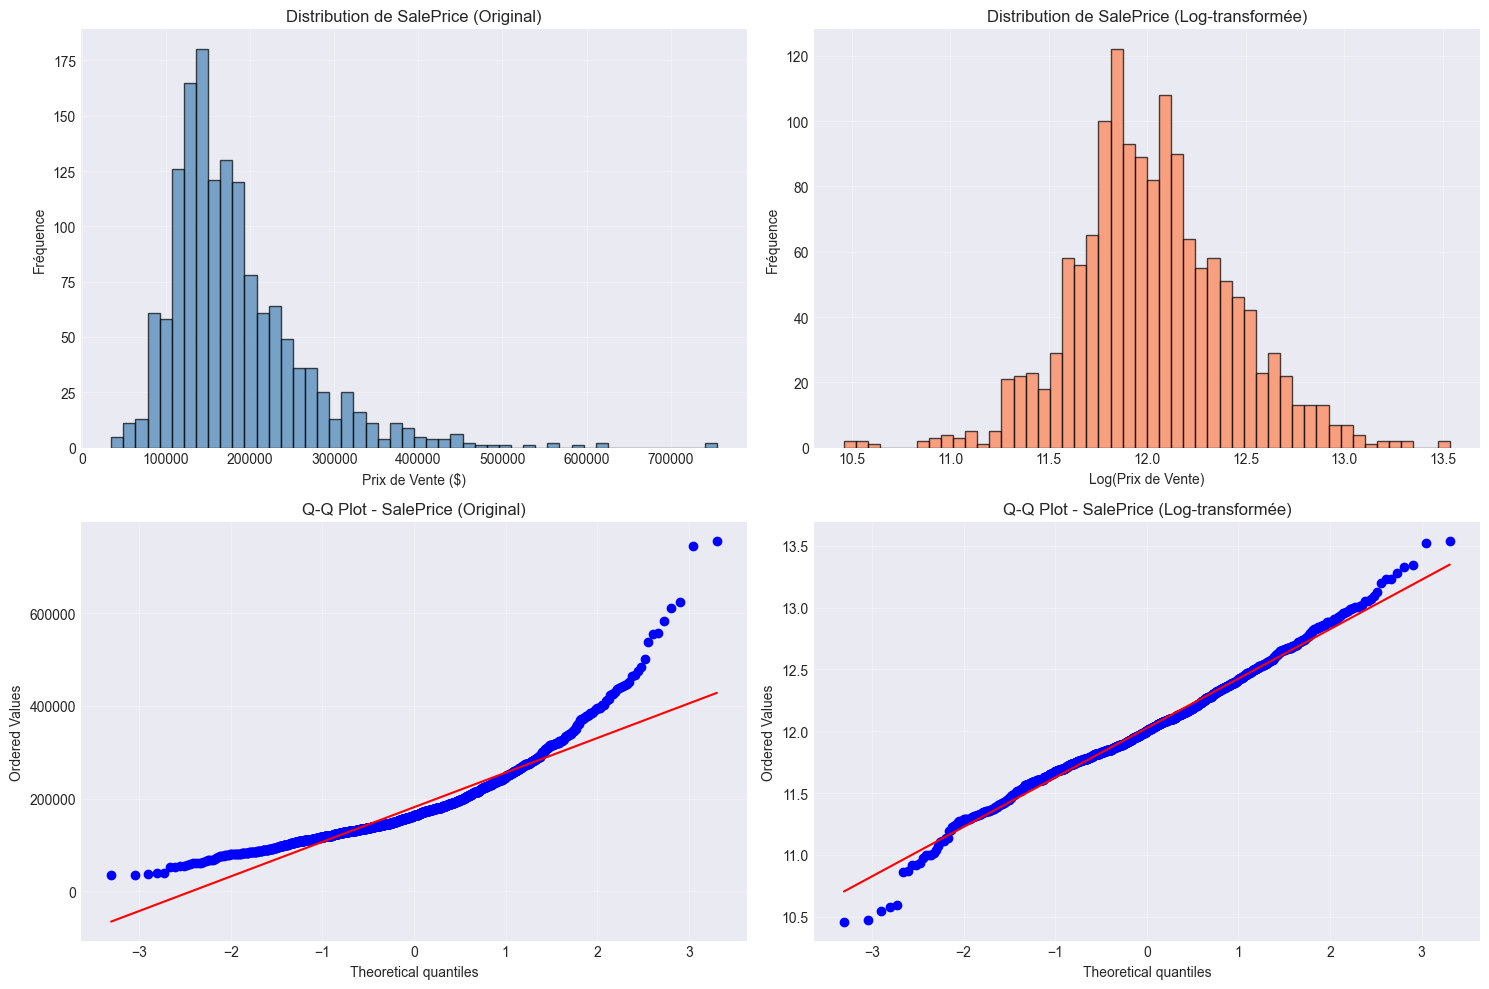


Observation: La transformation log1p normalise significativement la distribution.
La variable SalePrice_log sera utilisée pour l'entraînement du modèle.


In [14]:
# Transformation logarithmique de la variable cible
print("=" * 60)
print("TRANSFORMATION DE LA VARIABLE CIBLE (SalePrice)")
print("=" * 60)

# Analyser la distribution avant transformation
print("\nAvant transformation:")
print(f"   Skewness: {train_processed['SalePrice'].skew():.3f}")
print(f"   Kurtosis: {train_processed['SalePrice'].kurtosis():.3f}")
print(f"   Moyenne: ${train_processed['SalePrice'].mean():,.2f}")
print(f"   Médiane: ${train_processed['SalePrice'].median():,.2f}")

# Créer une copie pour la transformation
train_final = train_processed.copy()

# Appliquer la transformation logarithmique (log1p pour gérer les valeurs > 0)
train_final['SalePrice_log'] = np.log1p(train_final['SalePrice'])

# Analyser la distribution après transformation
print("\nAprès transformation log1p:")
print(f"   Skewness: {train_final['SalePrice_log'].skew():.3f}")
print(f"   Kurtosis: {train_final['SalePrice_log'].kurtosis():.3f}")
print(f"   Moyenne: {train_final['SalePrice_log'].mean():.3f}")
print(f"   Médiane: {train_final['SalePrice_log'].median():.3f}")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution avant transformation
axes[0, 0].hist(train_processed['SalePrice'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Prix de Vente ($)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution de SalePrice (Original)')
axes[0, 0].grid(True, alpha=0.3)

# Distribution après transformation
axes[0, 1].hist(train_final['SalePrice_log'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Log(Prix de Vente)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_title('Distribution de SalePrice (Log-transformée)')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot avant transformation
from scipy import stats
stats.probplot(train_processed['SalePrice'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - SalePrice (Original)')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot après transformation
stats.probplot(train_final['SalePrice_log'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot - SalePrice (Log-transformée)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/saleprice_transformation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nObservation: La transformation log1p normalise significativement la distribution.")
print("La variable SalePrice_log sera utilisée pour l'entraînement du modèle.")


## 14. Analyse de Multicolinéarité


ANALYSE DE MULTICOLINÉARITÉ

Variables fortement corrélées avec SalePrice (|r| > 0.5): 10
   OverallQual         :  0.798
   GrLivArea           :  0.736
   TotalBsmtSF         :  0.653
   GarageCars          :  0.640
   1stFlrSF            :  0.635
   GarageArea          :  0.634
   FullBath            :  0.564
   TotRmsAbvGrd        :  0.544
   YearBuilt           :  0.525
   YearRemodAdd        :  0.509

PAIRES DE VARIABLES FORTEMENT CORRÉLÉES ENTRE ELLES

3 paires avec corrélation > 0.7 (multicolinéarité potentielle):

   GrLivArea            <-> TotRmsAbvGrd        :  0.825
   TotalBsmtSF          <-> 1stFlrSF            :  0.795
   GarageCars           <-> GarageArea          :  0.882

RECOMMANDATIONS POUR LA MULTICOLINÉARITÉ

Pour chaque paire fortement corrélée:
   1. Conserver la variable la plus corrélée avec SalePrice
   2. Supprimer ou combiner les variables redondantes
   3. Utiliser des techniques de réduction de dimensionnalité (PCA)
   4. Appliquer une régularisation (L

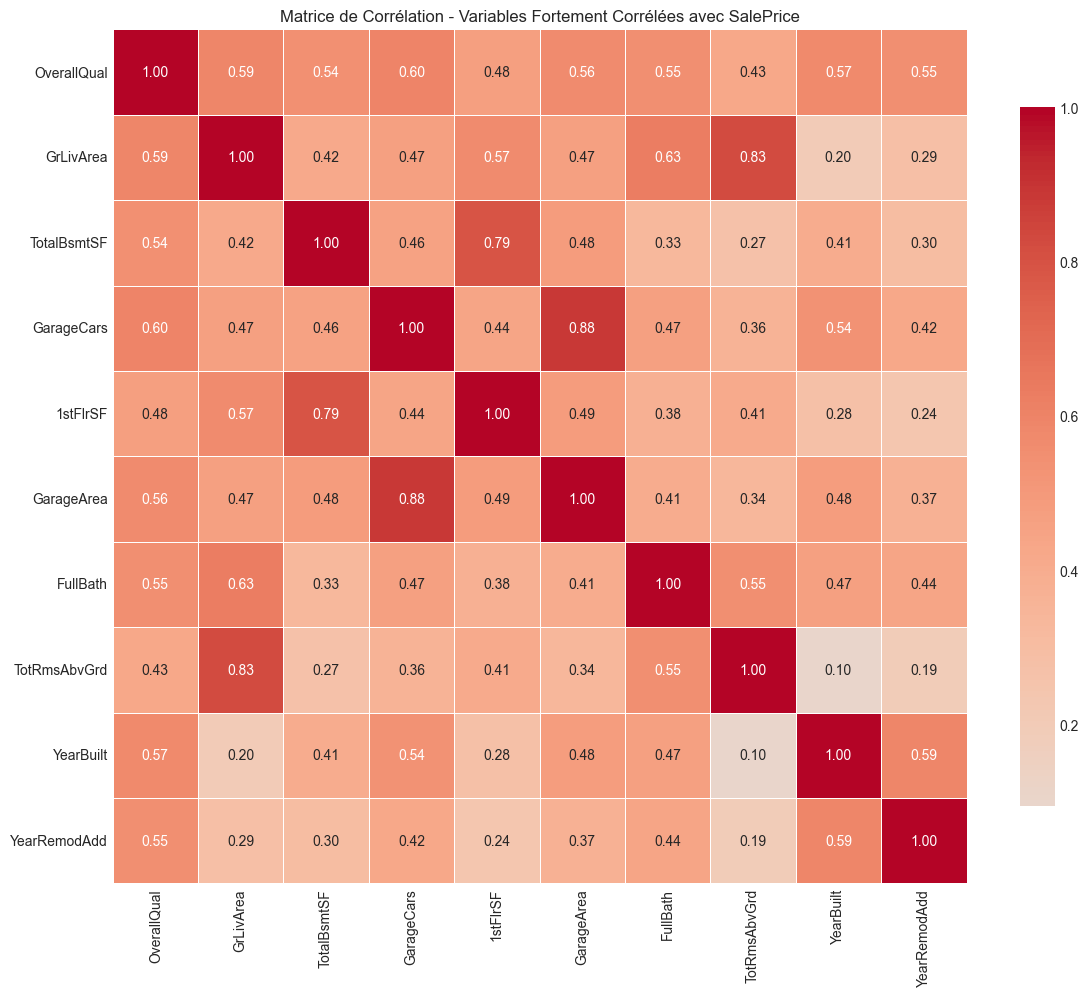

In [15]:
# Analyse de multicolinéarité entre variables fortement corrélées avec SalePrice
print("=" * 60)
print("ANALYSE DE MULTICOLINÉARITÉ")
print("=" * 60)

# Identifier les variables numériques fortement corrélées avec SalePrice
numeric_cols_final = train_final.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_final = [col for col in numeric_cols_final if col not in ['Id', 'SalePrice', 'SalePrice_log']]

# Calculer les corrélations avec SalePrice
correlations_with_target = train_final[numeric_cols_final + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
correlations_with_target = correlations_with_target.drop('SalePrice')

# Sélectionner les variables fortement corrélées (|r| > 0.5)
strong_corr_vars = correlations_with_target[abs(correlations_with_target) > 0.5].index.tolist()

print(f"\nVariables fortement corrélées avec SalePrice (|r| > 0.5): {len(strong_corr_vars)}")
for var in strong_corr_vars:
    print(f"   {var:20s}: {correlations_with_target[var]:6.3f}")

# Calculer la matrice de corrélation entre ces variables
if len(strong_corr_vars) > 1:
    corr_matrix_strong = train_final[strong_corr_vars].corr()
    
    # Identifier les paires de variables fortement corrélées entre elles
    print("\n" + "=" * 60)
    print("PAIRES DE VARIABLES FORTEMENT CORRÉLÉES ENTRE ELLES")
    print("=" * 60)
    
    high_corr_pairs = []
    for i in range(len(strong_corr_vars)):
        for j in range(i+1, len(strong_corr_vars)):
            var1 = strong_corr_vars[i]
            var2 = strong_corr_vars[j]
            corr_value = corr_matrix_strong.loc[var1, var2]
            
            if abs(corr_value) > 0.7:  # Seuil pour multicolinéarité
                high_corr_pairs.append({
                    'Variable 1': var1,
                    'Variable 2': var2,
                    'Corrélation': corr_value
                })
    
    if high_corr_pairs:
        print(f"\n{len(high_corr_pairs)} paires avec corrélation > 0.7 (multicolinéarité potentielle):\n")
        for pair in high_corr_pairs:
            print(f"   {pair['Variable 1']:20s} <-> {pair['Variable 2']:20s}: {pair['Corrélation']:6.3f}")
        
        # Recommandations
        print("\n" + "=" * 60)
        print("RECOMMANDATIONS POUR LA MULTICOLINÉARITÉ")
        print("=" * 60)
        print("\nPour chaque paire fortement corrélée:")
        print("   1. Conserver la variable la plus corrélée avec SalePrice")
        print("   2. Supprimer ou combiner les variables redondantes")
        print("   3. Utiliser des techniques de réduction de dimensionnalité (PCA)")
        print("   4. Appliquer une régularisation (L1/L2) dans le modèle")
        
        # Créer un DataFrame avec les recommandations
        recommendations = []
        for pair in high_corr_pairs:
            var1_corr = abs(correlations_with_target[pair['Variable 1']])
            var2_corr = abs(correlations_with_target[pair['Variable 2']])
            
            if var1_corr > var2_corr:
                keep = pair['Variable 1']
                remove = pair['Variable 2']
            else:
                keep = pair['Variable 2']
                remove = pair['Variable 1']
            
            recommendations.append({
                'Variable à conserver': keep,
                'Variable à considérer pour suppression': remove,
                'Corrélation entre elles': pair['Corrélation']
            })
        
        recommendations_df = pd.DataFrame(recommendations)
        print("\n" + recommendations_df.to_string(index=False))
        
        # Visualisation de la matrice de corrélation
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix_strong, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
        ax.set_title('Matrice de Corrélation - Variables Fortement Corrélées avec SalePrice')
        plt.tight_layout()
        plt.savefig('../output/figures/multicollinearity_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("\nAucune paire de variables avec corrélation > 0.7 détectée.")
        print("Pas de problème de multicolinéarité majeur entre les variables fortement corrélées avec SalePrice.")
else:
    print("\nMoins de 2 variables fortement corrélées - pas d'analyse de multicolinéarité nécessaire.")


## 14.5. Tests ANOVA pour les Variables Qualitatives

Les tests ANOVA (Analysis of Variance) permettent d'identifier les variables qualitatives qui ont un impact significatif sur le prix de vente. Un test ANOVA vérifie si les moyennes de SalePrice diffèrent significativement entre les groupes définis par une variable catégorielle.

**Hypothèses du test ANOVA:**
- H0: Les moyennes de SalePrice sont identiques pour tous les groupes
- H1: Au moins une moyenne diffère significativement

**Interprétation:**
- p-value < 0.05: La variable a un impact significatif sur le prix (rejet de H0)
- p-value >= 0.05: Pas d'impact significatif détecté

Variables qualitatives significatives (p < 0.05) doivent être intégrées dans le modèle.


TESTS ANOVA POUR LES VARIABLES QUALITATIVES

Nombre de variables qualitatives à tester: 43

RÉSULTATS DES TESTS ANOVA

Nombre total de variables testées: 42
Variables significatives (p < 0.05): 40
Variables très significatives (p < 0.01): 39

VARIABLES QUALITATIVES SIGNIFICATIVES (p < 0.05)

     Variable  F-statistique       p-value  Taille effet (R²)
 Neighborhood      67.901149 2.550138e-216           0.531754
    ExterQual     471.161079 6.771540e-214           0.492592
     BsmtQual     329.580688 5.497108e-202           0.475359
  KitchenQual     425.777023 1.543195e-198           0.467317
 GarageFinish     216.333031 4.819429e-116           0.308313
  FireplaceQu     121.670203 1.045522e-107           0.294979
   Foundation     100.994540  1.475388e-91           0.257774
   GarageType      81.165461  1.060297e-87           0.251028
 BsmtFinType1      65.969507  1.192177e-72           0.214092
    HeatingQC     118.106937  1.866375e-68           0.195831
   MasVnrType     114.311

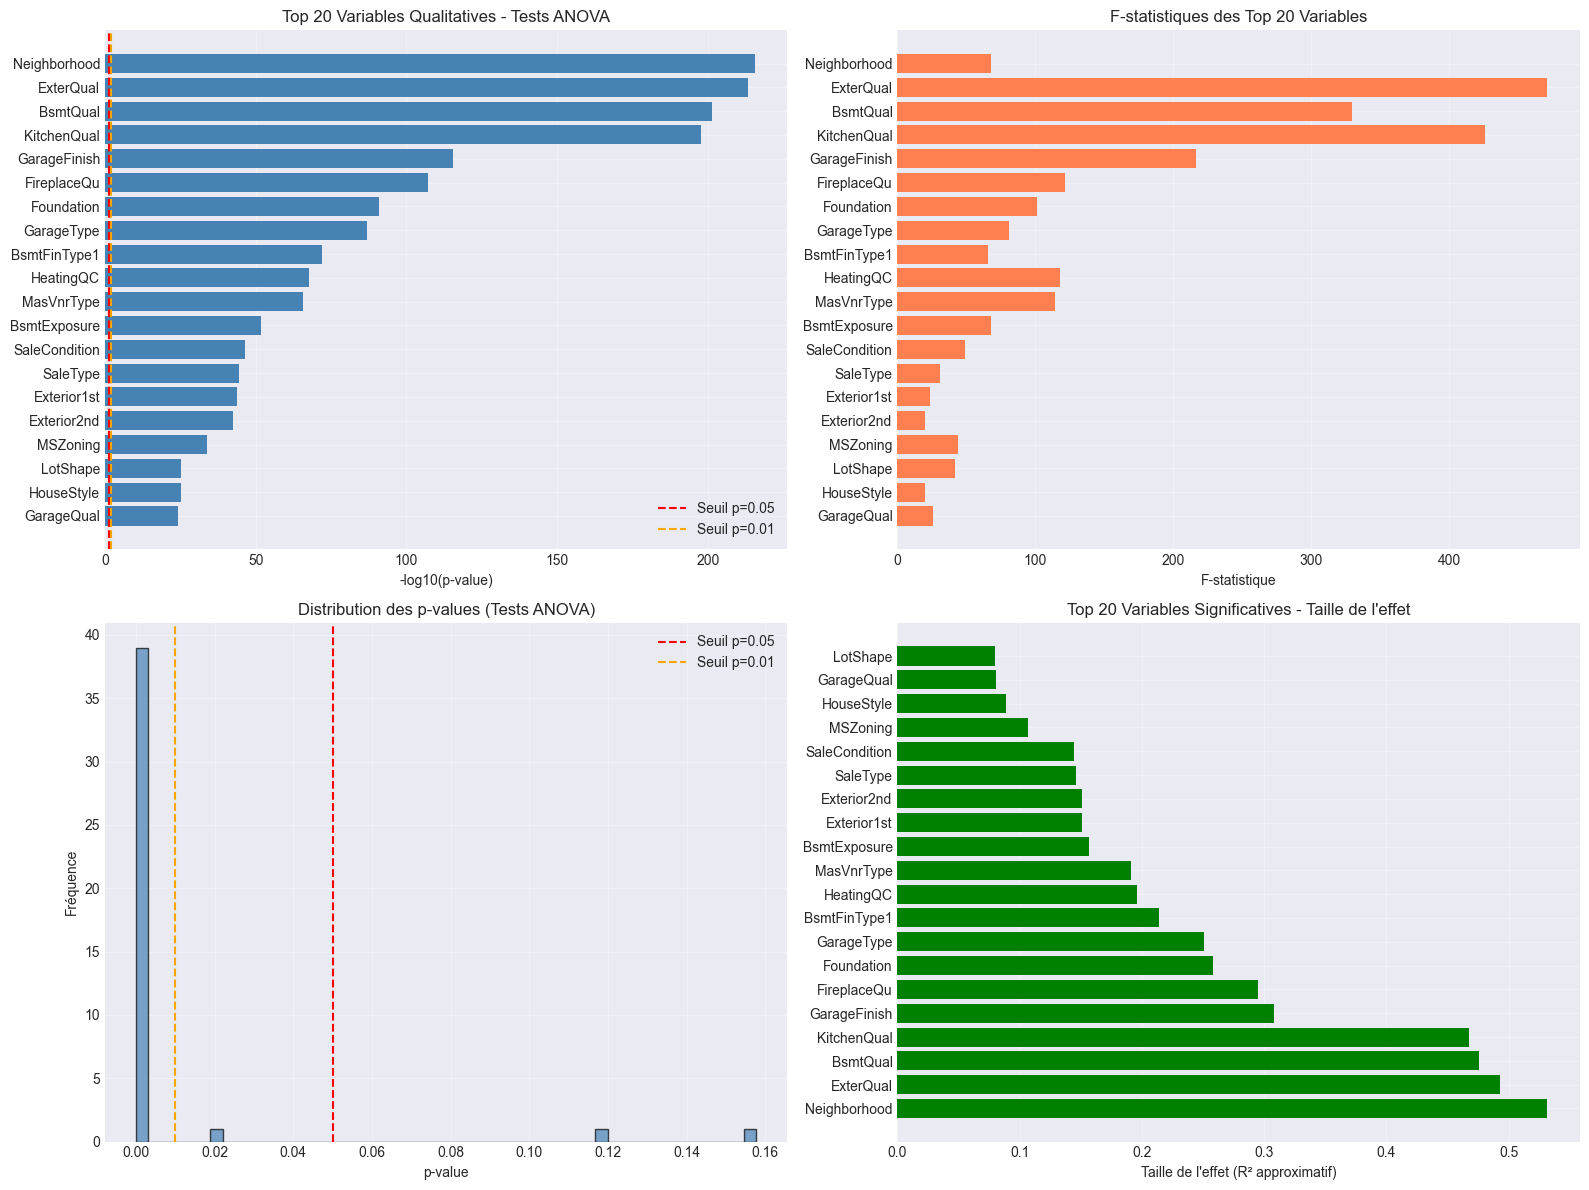


RECOMMANDATIONS POUR L'INTÉGRATION DANS LE MODÈLE

Variables qualitatives à INTÉGRER dans le modèle (p < 0.05):
   - Neighborhood              (p=0.0000, R²=0.5318)
   - ExterQual                 (p=0.0000, R²=0.4926)
   - BsmtQual                  (p=0.0000, R²=0.4754)
   - KitchenQual               (p=0.0000, R²=0.4673)
   - GarageFinish              (p=0.0000, R²=0.3083)
   - FireplaceQu               (p=0.0000, R²=0.2950)
   - Foundation                (p=0.0000, R²=0.2578)
   - GarageType                (p=0.0000, R²=0.2510)
   - BsmtFinType1              (p=0.0000, R²=0.2141)
   - HeatingQC                 (p=0.0000, R²=0.1958)
   - MasVnrType                (p=0.0000, R²=0.1906)
   - BsmtExposure              (p=0.0000, R²=0.1564)
   - SaleCondition             (p=0.0000, R²=0.1443)
   - SaleType                  (p=0.0000, R²=0.1464)
   - Exterior1st               (p=0.0000, R²=0.1510)

Total: 40 variables qualitatives significatives à intégrer



In [16]:
# Tests ANOVA pour les variables qualitatives
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("TESTS ANOVA POUR LES VARIABLES QUALITATIVES")
print("=" * 60)

# Identifier les variables catégorielles
categorical_cols_anova = train_final.select_dtypes(include=['object']).columns.tolist()

# Exclure 'Id' et 'SalePrice' si présents
categorical_cols_anova = [col for col in categorical_cols_anova if col not in ['Id', 'SalePrice']]

print(f"\nNombre de variables qualitatives à tester: {len(categorical_cols_anova)}")

# Stocker les résultats ANOVA
anova_results = []

# Effectuer les tests ANOVA pour chaque variable catégorielle
for col in categorical_cols_anova:
    # Grouper les données par catégorie
    groups = []
    group_names = []
    
    for category in train_final[col].unique():
        if pd.isna(category):
            continue
        
        group_data = train_final[train_final[col] == category]['SalePrice'].dropna()
        
        # Nécessaire d'avoir au moins 2 observations par groupe
        if len(group_data) >= 2:
            groups.append(group_data.values)
            group_names.append(str(category))
    
    # Effectuer le test ANOVA seulement s'il y a au moins 2 groupes
    if len(groups) >= 2:
        try:
            f_stat, p_value = f_oneway(*groups)
            
            # Calculer le nombre d'observations par groupe (moyenne)
            n_obs_per_group = np.mean([len(g) for g in groups])
            
            # Calculer la taille de l'effet (eta-squared η²)
            # η² = SS_between / SS_total
            # Où SS_between = somme des carrés entre les groupes
            #      SS_total = somme des carrés totale
            
            # Calculer la moyenne globale
            all_values = np.concatenate(groups)
            grand_mean = np.mean(all_values)
            
            # Calculer SS_between (somme des carrés entre les groupes)
            ss_between = 0
            for group in groups:
                group_mean = np.mean(group)
                n_i = len(group)
                ss_between += n_i * (group_mean - grand_mean) ** 2
            
            # Calculer SS_total (somme des carrés totale)
            ss_total = np.sum((all_values - grand_mean) ** 2)
            
            # Calculer eta-squared (η²)
            if ss_total > 0:
                effect_size = ss_between / ss_total
            else:
                effect_size = 0.0
            
            anova_results.append({
                'Variable': col,
                'F-statistique': f_stat,
                'p-value': p_value,
                'Significatif (p<0.05)': p_value < 0.05,
                'Très significatif (p<0.01)': p_value < 0.01,
                'Nombre de groupes': len(groups),
                'Nb obs/groupe (moy)': n_obs_per_group,
                'Taille effet (R²)': effect_size
            })
        except Exception as e:
            print(f"Erreur pour {col}: {e}")
            continue

# Créer un DataFrame avec les résultats
anova_df = pd.DataFrame(anova_results)

# Trier par p-value (du plus significatif au moins significatif)
anova_df = anova_df.sort_values('p-value')

print(f"\n{'='*60}")
print(f"RÉSULTATS DES TESTS ANOVA")
print(f"{'='*60}")

# Afficher les résultats
print(f"\nNombre total de variables testées: {len(anova_df)}")
print(f"Variables significatives (p < 0.05): {anova_df['Significatif (p<0.05)'].sum()}")
print(f"Variables très significatives (p < 0.01): {anova_df['Très significatif (p<0.01)'].sum()}")

# Afficher les variables significatives
print(f"\n{'='*60}")
print("VARIABLES QUALITATIVES SIGNIFICATIVES (p < 0.05)")
print(f"{'='*60}")
significant_vars = anova_df[anova_df['Significatif (p<0.05)']].copy()
if len(significant_vars) > 0:
    print(f"\n{significant_vars[['Variable', 'F-statistique', 'p-value', 'Taille effet (R²)']].to_string(index=False)}")
else:
    print("\nAucune variable qualitative significative détectée (p < 0.05)")

# Afficher les top 20 variables les plus significatives
print(f"\n{'='*60}")
print("TOP 20 VARIABLES LES PLUS SIGNIFICATIVES")
print(f"{'='*60}")
top_20 = anova_df.head(20)
print(f"\n{top_20[['Variable', 'F-statistique', 'p-value', 'Taille effet (R²)']].to_string(index=False)}")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Graphique des p-values (top 20)
top_20_viz = anova_df.head(20).sort_values('p-value', ascending=True)
axes[0, 0].barh(range(len(top_20_viz)), -np.log10(top_20_viz['p-value']), color='steelblue')
axes[0, 0].axvline(-np.log10(0.05), color='red', linestyle='--', label='Seuil p=0.05')
axes[0, 0].axvline(-np.log10(0.01), color='orange', linestyle='--', label='Seuil p=0.01')
axes[0, 0].set_yticks(range(len(top_20_viz)))
axes[0, 0].set_yticklabels(top_20_viz['Variable'])
axes[0, 0].set_xlabel('-log10(p-value)')
axes[0, 0].set_title('Top 20 Variables Qualitatives - Tests ANOVA')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].invert_yaxis()

# 2. Graphique des F-statistiques (top 20)
axes[0, 1].barh(range(len(top_20_viz)), top_20_viz['F-statistique'], color='coral')
axes[0, 1].set_yticks(range(len(top_20_viz)))
axes[0, 1].set_yticklabels(top_20_viz['Variable'])
axes[0, 1].set_xlabel('F-statistique')
axes[0, 1].set_title('F-statistiques des Top 20 Variables')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].invert_yaxis()

# 3. Distribution des p-values
axes[1, 0].hist(anova_df['p-value'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].axvline(0.05, color='red', linestyle='--', label='Seuil p=0.05')
axes[1, 0].axvline(0.01, color='orange', linestyle='--', label='Seuil p=0.01')
axes[1, 0].set_xlabel('p-value')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution des p-values (Tests ANOVA)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Taille de l'effet (R²) pour les variables significatives
significant_for_plot = anova_df[anova_df['Significatif (p<0.05)']].head(20)
if len(significant_for_plot) > 0:
    axes[1, 1].barh(range(len(significant_for_plot)), 
                    significant_for_plot['Taille effet (R²)'].sort_values(), 
                    color='green')
    axes[1, 1].set_yticks(range(len(significant_for_plot)))
    axes[1, 1].set_yticklabels(significant_for_plot.sort_values('Taille effet (R²)')['Variable'])
    axes[1, 1].set_xlabel('Taille de l\'effet (R² approximatif)')
    axes[1, 1].set_title('Top 20 Variables Significatives - Taille de l\'effet')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].invert_yaxis()
else:
    axes[1, 1].text(0.5, 0.5, 'Aucune variable significative', 
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Taille de l\'effet')

plt.tight_layout()
plt.savefig('../output/figures/anova_tests.png', dpi=300, bbox_inches='tight')
plt.show()

# Recommandations
print(f"\n{'='*60}")
print("RECOMMANDATIONS POUR L'INTÉGRATION DANS LE MODÈLE")
print(f"{'='*60}")

if len(significant_vars) > 0:
    print(f"\nVariables qualitatives significative (p < 0.05):")
    for var in significant_vars['Variable'].head(15):
        p_val = significant_vars[significant_vars['Variable'] == var]['p-value'].values[0]
        effect = significant_vars[significant_vars['Variable'] == var]['Taille effet (R²)'].values[0]
        print(f"   - {var:25s} (p={p_val:.4f}, R²={effect:.4f})")
    
    print(f"\nTotal: {len(significant_vars)} variables qualitatives significatives")
else:
    print("\nAucune variable qualitative significative détectée.")
    print("Cela ne signifie pas nécessairement qu'elles ne sont pas importantes,")
    print("mais qu'aucun effet significatif n'a été détecté avec le test ANOVA standard.")

print(f"\n{'='*60}")


## 15. Sauvegarde des Données Finales


In [17]:
# Sauvegarder les données finales pour l'entraînement du modèle
print("=" * 60)
print("SAUVEGARDE DES DONNÉES FINALES")
print("=" * 60)

# Créer le dossier de sortie s'il n'existe pas
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Créer test_final à partir de test_processed (sans transformation log car pas de SalePrice)
test_final = test_processed.copy()

# Sauvegarder les données d'entraînement finales
train_final_path = output_dir / "train_final.csv"
train_final.to_csv(train_final_path, index=False)

# Sauvegarder les données de test finales
test_final_path = output_dir / "test_final.csv"
test_final.to_csv(test_final_path, index=False)

print(f"\nDonnées d'entraînement finales sauvegardées:")
print(f"   - Chemin: {train_final_path}")
print(f"   - Forme: {train_final.shape}")
print(f"   - Colonnes: {train_final.shape[1]}")
print(f"   - Observations: {train_final.shape[0]}")

print(f"\nDonnées de test finales sauvegardées:")
print(f"   - Chemin: {test_final_path}")
print(f"   - Forme: {test_final.shape}")
print(f"   - Colonnes: {test_final.shape[1]}")
print(f"   - Observations: {test_final.shape[0]}")

# Vérification finale
print("\n" + "=" * 60)
print("VÉRIFICATION FINALE - TRAIN")
print("=" * 60)
print(f"   Valeurs manquantes: {train_final.isnull().sum().sum()}")
print(f"   Variable cible originale (SalePrice): {'Présente' if 'SalePrice' in train_final.columns else 'Absente'}")
print(f"   Variable cible transformée (SalePrice_log): {'Présente' if 'SalePrice_log' in train_final.columns else 'Absente'}")

if 'SalePrice_log' in train_final.columns:
    print(f"   Skewness de SalePrice_log: {train_final['SalePrice_log'].skew():.3f}")
    print(f"   (Valeur proche de 0 = distribution normalisée)")

print("\n" + "=" * 60)
print("VÉRIFICATION FINALE - TEST")
print("=" * 60)
print(f"   Valeurs manquantes: {test_final.isnull().sum().sum()}")
print(f"   Observations: {test_final.shape[0]}")

print("\n" + "=" * 60)
print("DONNÉES PRÊTES POUR L'ENTRAÎNEMENT DU MODÈLE")
print("=" * 60)
print("\nLes données finales sont sauvegardées et prêtes pour:")
print("   1. Feature engineering (si nécessaire)")
print("   2. Sélection de variables (gestion de la multicolinéarité)")
print("   3. Entraînement du modèle avec SalePrice_log comme variable cible")
print("   4. Transformation inverse (expm1) pour les prédictions finales")
print("\nFichiers sauvegardés:")
print(f"   - {train_final_path}")
print(f"   - {test_final_path}")


SAUVEGARDE DES DONNÉES FINALES

Données d'entraînement finales sauvegardées:
   - Chemin: ..\data\processed\train_final.csv
   - Forme: (1460, 82)
   - Colonnes: 82
   - Observations: 1460

Données de test finales sauvegardées:
   - Chemin: ..\data\processed\test_final.csv
   - Forme: (1459, 80)
   - Colonnes: 80
   - Observations: 1459

VÉRIFICATION FINALE - TRAIN
   Valeurs manquantes: 0
   Variable cible originale (SalePrice): Présente
   Variable cible transformée (SalePrice_log): Présente
   Skewness de SalePrice_log: 0.130
   (Valeur proche de 0 = distribution normalisée)

VÉRIFICATION FINALE - TEST
   Valeurs manquantes: 0
   Observations: 1459

DONNÉES PRÊTES POUR L'ENTRAÎNEMENT DU MODÈLE

Les données finales sont sauvegardées et prêtes pour:
   1. Feature engineering (si nécessaire)
   2. Sélection de variables (gestion de la multicolinéarité)
   3. Entraînement du modèle avec SalePrice_log comme variable cible
   4. Transformation inverse (expm1) pour les prédictions finales


In [18]:
# Générer un rapport récapitulatif
print("=" * 60)
print("RAPPORT RÉCAPITULATIF")
print("=" * 60)

print("\nRESUME DU DATASET")
print(f"   Observations d'entrainement: {train_df.shape[0]:,}")
print(f"   Variables totales: {train_df.shape[1]}")
print(f"   Variables numeriques: {len(numeric_cols)}")
print(f"   Variables categorielles: {len(categorical_cols)}")

print("\nVARIABLE CIBLE (SalePrice)")
print(f"   Plage: ${train_df['SalePrice'].min():,.0f} - ${train_df['SalePrice'].max():,.0f}")
print(f"   Moyenne: ${train_df['SalePrice'].mean():,.0f}")
print(f"   Mediane: ${train_df['SalePrice'].median():,.0f}")
print(f"   Skewness: {train_df['SalePrice'].skew():.3f}")

print("\nVALEURS MANQUANTES")
missing_count = train_df.isnull().sum().sum()
missing_cols_count = (train_df.isnull().sum() > 0).sum()
print(f"   Total de valeurs manquantes: {missing_count:,}")
print(f"   Colonnes avec valeurs manquantes: {missing_cols_count}")

print("\nTOP 5 VARIABLES CORRELEES AVEC SALEPRICE")
top_5_corr = correlations.drop('SalePrice').head(5)
for var, corr in top_5_corr.items():
    print(f"   {var:20s}: {corr:.3f}")

print("\nExploration terminee!")
print("=" * 60)


RAPPORT RÉCAPITULATIF

RESUME DU DATASET
   Observations d'entrainement: 1,460
   Variables totales: 81
   Variables numeriques: 38
   Variables categorielles: 43

VARIABLE CIBLE (SalePrice)
   Plage: $34,900 - $755,000
   Moyenne: $181,292
   Mediane: $163,000
   Skewness: 1.876

VALEURS MANQUANTES
   Total de valeurs manquantes: 0
   Colonnes avec valeurs manquantes: 0

TOP 5 VARIABLES CORRELEES AVEC SALEPRICE
   OverallQual         : 0.798
   GrLivArea           : 0.736
   TotalBsmtSF         : 0.653
   GarageCars          : 0.640
   1stFlrSF            : 0.635

Exploration terminee!
